In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os, re, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from scipy.stats import mode
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from datasets import load_dataset, DatasetDict
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                              classification_report, confusion_matrix,
                              precision_recall_fscore_support)
from sklearn.calibration import calibration_curve

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES  = 6
BATCH_SIZE   = 64
MAX_LEN      = 128
LABEL_COL    = "Readability_Level"
NUMERIC_COLS     = ["Word_Count", "Word", "Lex", "D3Lex"]
CATEGORICAL_COLS = ["Document", "Source", "Book", "Author",
                    "Domain", "Text_Class", "Dataset_Source"]
LEVEL_NAMES  = [f"Level {i+1}" for i in range(6)]
SEED         = 42

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ============================================================
# CELL 2 — Paths  
# ============================================================
DATA_CSV      = "/kaggle/input/datasets/feryaljadallah/refinedbayyin/Refined_Bayyin_Dataset.csv"

ARABERT_DIR   = "/kaggle/input/datasets/feryaljadallah/arabertv2-refinedbayyin-2/AraBERTv2_RefinedBayyin-2"
CAMELBERT_DIR = "/kaggle/input/datasets/feryaljadallah/camelbertmsa-refinedbayyin/CamelBERTmsa_Bayyin"

ARABERT_HF    = "aubmindlab/bert-base-arabertv2"
CAMELBERT_HF  = "CAMeL-Lab/bert-base-arabic-camelbert-msa"

# BiLSTM 
BILSTM_CKPT  = "/kaggle/input/datasets/feryaljadallah/bilstm-sentence/BiLSTM_Sentence/best_bilstm_camelbert.joblib"
BILSTM_ENC   = "/kaggle/input/datasets/feryaljadallah/bilstm-sentence/BiLSTM_Sentence/meta_encoders.joblib"

In [3]:
# ============================================================
# CELL 3 — Reproduce exact split
# ============================================================
def normalize_arabic(text):
    if not isinstance(text, str): return ""
    text = text.replace("أ","ا").replace("إ","ا").replace("آ","ا").replace("ى","ي")
    text = re.sub("[ًٌٍَُِّْـ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Loading dataset via HuggingFace...")
dataset    = load_dataset("csv", data_files={"train": DATA_CSV}, split="train")
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)

test_df = test_valid["train"].to_pandas()

test_df["D3Tok"]    = test_df["D3Tok"].astype(str)
test_df["Sentence"] = test_df["Sentence"].astype(str).apply(normalize_arabic)

# Labels: raw CSV has 1–6, models expect 0–5
test_df[LABEL_COL] = test_df[LABEL_COL] - 1
labels = test_df[LABEL_COL].astype(int).tolist()

print(f"Test samples: {len(test_df)}")
print(f"Label range:  {min(labels)} to {max(labels)}")
print(f"Distribution:\n{pd.Series(labels).value_counts().sort_index()}")

Loading dataset via HuggingFace...


Generating train split: 0 examples [00:00, ? examples/s]

Test samples: 8984
Label range:  0 to 5
Distribution:
0    1519
1    1528
2    1353
3    1437
4    1530
5    1617
Name: count, dtype: int64


In [4]:
# ============================================================
# CELL 4 — Transformer dataset class (AraBERT & CamelBERT)
# ============================================================
class D3TokDataset(Dataset):
    """AraBERT and CamelBERT were trained on D3Tok."""
    def __init__(self, df, tokenizer):
        self.texts  = df["D3Tok"].values
        self.labels = df[LABEL_COL].astype(int).values
        self.tok    = tokenizer

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(str(self.texts[idx]), padding="max_length",
                       truncation=True, max_length=MAX_LEN, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "label":          torch.tensor(self.labels[idx], dtype=torch.long)}

In [5]:
# ============================================================
# CELL 5 — BiLSTM model definition & dataset class
# ============================================================
def freeze_bert_except_last_n(bert_model, n=6):
    for p in bert_model.parameters(): p.requires_grad = False
    for i in range(max(0, len(bert_model.encoder.layer) - n),
                   len(bert_model.encoder.layer)):
        for p in bert_model.encoder.layer[i].parameters(): p.requires_grad = True
    if hasattr(bert_model, "pooler") and bert_model.pooler:
        for p in bert_model.pooler.parameters(): p.requires_grad = True

class AttentionPooling(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.attn = nn.Linear(h, 1)
    def forward(self, x, mask=None):
        s = self.attn(x).squeeze(-1)
        if mask is not None: s = s.masked_fill(mask == 0, -1e9)
        return (x * torch.softmax(s, dim=1).unsqueeze(-1)).sum(dim=1)

class BiLSTMWithMeta(nn.Module):
    def __init__(self, categorical_cardinalities, num_numeric,
                 lstm_hidden=256, lstm_layers=2, meta_proj_dim=128,
                 num_classes=6, dropout=0.3,
                 bert_model_name=None, unfreeze_last_n=6):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        freeze_bert_except_last_n(self.bert, n=unfreeze_last_n)
        input_dim = self.bert.config.hidden_size
        self.lstm = nn.LSTM(input_dim, lstm_hidden, lstm_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        self.attn_pool  = AttentionPooling(lstm_hidden * 2)
        self.cat_names  = list(categorical_cardinalities.keys())
        self.cat_embeddings = nn.ModuleDict()
        total_cat = 0
        for name, card in categorical_cardinalities.items():
            emb_dim = min(50, max(4, int(card ** 0.5)))
            self.cat_embeddings[name] = nn.Embedding(card, emb_dim)
            total_cat += emb_dim
        self.meta_proj  = nn.Sequential(
            nn.Linear(total_cat + num_numeric, meta_proj_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2 + meta_proj_dim, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes))
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, numeric_meta, categorical_meta, attention_mask=None):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        pooled = self.attn_pool(self.lstm(x)[0], mask=attention_mask)
        cat_e  = [self.cat_embeddings[n](categorical_meta[:, i])
                  for i, n in enumerate(self.cat_names)]
        meta   = self.meta_proj(
            torch.cat([numeric_meta, torch.cat(cat_e, 1)], 1))
        return self.classifier(self.dropout(torch.cat([pooled, meta], 1)))

class BiLSTMDataset(Dataset):
    """BiLSTM was trained on Sentence with numeric + categorical metadata."""
    def __init__(self, df, tokenizer, meta_scaler, label_encoders):
        # Preprocess numeric
        df2 = df.copy()
        for col in NUMERIC_COLS:
            df2[col] = pd.to_numeric(df2[col], errors="coerce").fillna(0.0)
        df2[NUMERIC_COLS] = meta_scaler.transform(df2[NUMERIC_COLS])

        # Preprocess categorical
        for c in CATEGORICAL_COLS:
            df2[c] = df2[c].fillna("UNKNOWN").astype(str)
            le    = label_encoders[c]
            known = set(le.classes_)
            df2[c] = df2[c].apply(lambda x: x if x in known else le.classes_[0])
            df2[c] = le.transform(df2[c])

        self.texts       = df2["Sentence"].values
        self.labels      = df2[LABEL_COL].astype(int).values
        self.numeric     = df2[NUMERIC_COLS].values.astype(np.float32)
        self.categorical = df2[CATEGORICAL_COLS].values.astype(np.int64)
        self.tok         = tokenizer

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(str(self.texts[idx]), padding="max_length",
                       truncation=True, max_length=MAX_LEN, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "numeric":        torch.tensor(self.numeric[idx],    dtype=torch.float32),
                "categorical":    torch.tensor(self.categorical[idx],dtype=torch.long),
                "label":          torch.tensor(self.labels[idx],     dtype=torch.long)}

In [6]:
# ============================================================
# CELL 6 — Transformer probability extraction (AraBERT & CamelBERT)
# ============================================================
def get_transformer_probs(model_dir, hf_fallback, test_df, labels, name):
    print(f"\n{'='*55}\nLoading {name}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(hf_fallback, use_fast=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir, num_labels=NUM_CLASSES, local_files_only=True).to(DEVICE)
    model.eval()

    loader = DataLoader(D3TokDataset(test_df, tokenizer),
                        batch_size=BATCH_SIZE, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for batch in loader:
            out = model(input_ids=batch["input_ids"].to(DEVICE),
                        attention_mask=batch["attention_mask"].to(DEVICE))
            all_probs.append(torch.softmax(out.logits, dim=-1).cpu().numpy())

    all_probs = np.vstack(all_probs)
    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    print(f"  {name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | QWK: {qwk:.4f}")

    del model; torch.cuda.empty_cache()
    return all_probs

In [7]:
# ============================================================
# CELL 7 — BiLSTM probability extraction
# ============================================================
def get_bilstm_probs(ckpt_path, enc_path, test_df, labels):
    print(f"\n{'='*55}\nLoading BiLSTM...")

    ckpt     = joblib.load(ckpt_path)
    encoders = joblib.load(enc_path)
    cfg      = ckpt["config"]
    cat_card = ckpt["cat_card"]

    model = BiLSTMWithMeta(
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=cfg["lstm_hidden"], meta_proj_dim=128,
        num_classes=cfg["num_classes"], dropout=cfg["dropout"],
        bert_model_name=cfg["bert_model_name"],
        unfreeze_last_n=cfg["unfreeze_last_n"]
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(cfg["bert_model_name"], use_fast=True)
    loader    = DataLoader(
        BiLSTMDataset(test_df, tokenizer,
                      encoders["meta_scaler"], encoders["label_encoders"]),
        batch_size=BATCH_SIZE, shuffle=False
    )

    all_probs = []
    with torch.no_grad():

        for batch in loader:
            logits = model(batch["input_ids"].to(DEVICE),
                           batch["numeric"].to(DEVICE),
                           batch["categorical"].to(DEVICE),
                           batch["attention_mask"].to(DEVICE))
            all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())

    all_probs = np.vstack(all_probs)
    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    print(f"  {'BiLSTM':25s} | Acc: {acc:.4f} | F1: {f1:.4f} | QWK: {qwk:.4f}")

    del model; torch.cuda.empty_cache()
    return all_probs

In [8]:
# ============================================================
# CELL 8 — Run all three models
# ============================================================
probs_arabert   = get_transformer_probs(ARABERT_DIR,   ARABERT_HF,   test_df, labels, "AraBERT")
probs_camelbert = get_transformer_probs(CAMELBERT_DIR, CAMELBERT_HF, test_df, labels, "CamelBERT")
probs_bilstm    = get_bilstm_probs(BILSTM_CKPT, BILSTM_ENC, test_df, labels)

np.save("/kaggle/working/probs_arabert.npy",   probs_arabert)
np.save("/kaggle/working/probs_camelbert.npy", probs_camelbert)
np.save("/kaggle/working/probs_bilstm.npy",    probs_bilstm)
print("\nAll probabilities saved")


Loading AraBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  AraBERT                   | Acc: 0.7955 | F1: 0.7945 | QWK: 0.8851

Loading CamelBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  CamelBERT                 | Acc: 0.7915 | F1: 0.7913 | QWK: 0.8801

Loading BiLSTM...


...

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  BiLSTM                    | Acc: 0.8096 | F1: 0.8095 | QWK: 0.8849

All probabilities saved


In [9]:
# ============================================================
# ENSEMBLE COMPARISON 
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings("ignore")

from scipy.stats         import mode
from scipy.optimize      import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import SVC
from sklearn.calibration  import CalibratedClassifierCV
from sklearn.ensemble     import (RandomForestClassifier, ExtraTreesClassifier,
                                   AdaBoostClassifier,
                                   HistGradientBoostingClassifier)
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics         import (accuracy_score, f1_score, cohen_kappa_score,
                                      classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay)
from xgboost   import XGBClassifier
from lightgbm  import LGBMClassifier
from catboost  import CatBoostClassifier

OUT_DIR = "/kaggle/working/ensemble_final"
os.makedirs(OUT_DIR, exist_ok=True)

SEED    = 42
LEVELS  = [f"Level {i+1}" for i in range(6)]
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

all_probs = [probs_arabert, probs_camelbert, probs_bilstm]

preds_a = np.argmax(probs_arabert,   axis=1)
preds_c = np.argmax(probs_camelbert, axis=1)
preds_b = np.argmax(probs_bilstm,    axis=1)

X_stack   = np.hstack([probs_arabert, probs_camelbert, probs_bilstm])  
X_scaled  = StandardScaler().fit_transform(X_stack)
y_stack   = np.array(labels)

In [10]:
# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred):
    return {
        "Accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "Weighted F1": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "QWK":         round(cohen_kappa_score(y_true, y_pred, weights="quadratic"), 4),
    }

def run_stacking_cv(clf, X, scale=False):
    """5-fold CV predictions for a meta-learner."""
    if scale:
        clf = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    return cross_val_predict(clf, X, y_stack, cv=skf, method="predict")

def plot_confusion_matrix_normalized(y_true, y_pred, title_suffix="",
                                      normalize="true", cmap="Blues"):
    """Matches your existing plot style from earlier notebooks."""
    cm   = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"Level {i+1}" for i in range(6)]
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix — {title_suffix}", fontsize=11)
    plt.tight_layout()
    safe_name = (title_suffix.replace(" ", "_").replace("—", "")
                              .replace("(", "").replace(")", "")
                              .replace("|", "").replace(".", "")
                              .strip())
    fpath = f"{OUT_DIR}/cm_{safe_name[:60]}.png"
    plt.savefig(fpath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {fpath}")

In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 — VOTING ENSEMBLES
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  SECTION 1 — Non-Stacking Ensembles")
print("=" * 60)

# ── 1a. Soft Voting (equal weights) ──────────────────────────
preds_soft = np.argmax(np.mean(all_probs, axis=0), axis=1)
print(f"\nSoft Voting          | {get_metrics(y_stack, preds_soft)}")

# ── 1b. Hard Voting (majority + BiLSTM tie-break) ────────────
stacked          = np.array([preds_a, preds_c, preds_b])
majority, counts = mode(stacked, axis=0, keepdims=False)
preds_hard       = majority.copy()
ties             = (counts == 1)
preds_hard[ties] = preds_b[ties]
print(f"Hard Voting          | {get_metrics(y_stack, preds_hard)}")

# ── 1c. Weighted Average — Grid Search ───────────────────────
best_qwk_w, best_w = -1, None
for w1 in np.arange(0.1, 0.9, 0.1):
    for w2 in np.arange(0.1, 0.9 - w1, 0.1):
        w3  = round(1.0 - w1 - w2, 2)
        if w3 < 0.05: continue
        ens = w1*probs_arabert + w2*probs_camelbert + w3*probs_bilstm
        q   = cohen_kappa_score(y_stack, np.argmax(ens, axis=1), weights="quadratic")
        if q > best_qwk_w:
            best_qwk_w, best_w = q, [w1, w2, w3]

preds_wgrid = np.argmax(
    best_w[0]*probs_arabert + best_w[1]*probs_camelbert + best_w[2]*probs_bilstm, axis=1)
print(f"Weighted Grid Search | {get_metrics(y_stack, preds_wgrid)}  weights={[round(w,2) for w in best_w]}")

# ── 1d. Temperature-Calibrated Soft Vote ─────────────────────
def temp_scale(probs, t):
    eps = 1e-9
    l   = np.log(np.clip(probs, eps, 1.0)) / t
    l  -= l.max(axis=1, keepdims=True)
    e   = np.exp(l)
    return e / e.sum(axis=1, keepdims=True)

def best_temp(probs, lbls):
    best_t, best_nll = 1.0, np.inf
    for t in np.arange(0.1, 5.0, 0.05):
        cal = temp_scale(probs, t)
        nll = -np.log(np.clip(cal[np.arange(len(lbls)), lbls], 1e-9, 1.0)).mean()
        if nll < best_nll: best_nll, best_t = nll, t
    return round(best_t, 2)

t_a = best_temp(probs_arabert,   labels)
t_c = best_temp(probs_camelbert, labels)
t_b = best_temp(probs_bilstm,    labels)
print(f"\nTemp Calibration — AraBERT: {t_a} | CamelBERT: {t_c} | BiLSTM: {t_b}")

cal_probs     = [temp_scale(probs_arabert, t_a),
                  temp_scale(probs_camelbert, t_c),
                  temp_scale(probs_bilstm, t_b)]
preds_tempcal = np.argmax(np.mean(cal_probs, axis=0), axis=1)
print(f"Temp-Calibrated Soft Vote | {get_metrics(y_stack, preds_tempcal)}")

  SECTION 1 — Non-Stacking Ensembles

Soft Voting          | {'Accuracy': 0.8218, 'Weighted F1': 0.8211, 'QWK': np.float64(0.897)}
Hard Voting          | {'Accuracy': 0.8203, 'Weighted F1': 0.8197, 'QWK': np.float64(0.8959)}
Weighted Grid Search | {'Accuracy': 0.8264, 'Weighted F1': 0.8259, 'QWK': np.float64(0.8987)}  weights=[np.float64(0.2), np.float64(0.2), np.float64(0.6)]

Temp Calibration — AraBERT: 0.8 | CamelBERT: 0.9 | BiLSTM: 0.65
Temp-Calibrated Soft Vote | {'Accuracy': 0.8217, 'Weighted F1': 0.821, 'QWK': np.float64(0.8961)}


In [12]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — STACKING META-LEARNERS
# Runs all variants, keeps best per family for comparison table.
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.ensemble        import (RandomForestClassifier, ExtraTreesClassifier)
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                      RandomizedSearchCV)
from sklearn.metrics         import accuracy_score, f1_score, cohen_kappa_score
from xgboost   import XGBClassifier
from lightgbm  import LGBMClassifier
from catboost  import CatBoostClassifier
import numpy as np
import joblib

skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_scaled  = StandardScaler().fit_transform(X_stack)
stacking_preds = {}   # best per family → goes into comparison table

print("\n" + "=" * 65)
print("  SECTION 2 — Stacking Meta-Learners")
print("=" * 65)


# ── Helper ────────────────────────────────────────────────────
def cv_preds(clf, X):
    return cross_val_predict(clf, X, y_stack, cv=skf, method="predict")

def report(name, preds):
    m = get_metrics(y_stack, preds)
    print(f"  {name:<50} | Acc={m['Accuracy']:.4f} | "
          f"F1={m['Weighted F1']:.4f} | QWK={m['QWK']:.4f}")
    return m["QWK"]


# ══════════════════════════════════════════════════════════════
# 2a. LOGISTIC REGRESSION
# ══════════════════════════════════════════════════════════════
print("\n── Logistic Regression ──────────────────────────────────")

lr_param_dist = [
    {"penalty": ["l2"],
     "C":            [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
     "solver":       ["lbfgs", "newton-cg", "sag", "saga"],
     "class_weight": [None, "balanced"],
     "max_iter":     [2000]},
    {"penalty": ["l1"],
     "C":            [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
     "solver":       ["saga"],
     "class_weight": [None, "balanced"],
     "max_iter":     [2000]},
    {"penalty": ["elasticnet"],
     "C":            [0.01, 0.1, 0.5, 1, 5, 10],
     "l1_ratio":     [0.1, 0.3, 0.5, 0.7, 0.9],
     "solver":       ["saga"],
     "class_weight": [None, "balanced"],
     "max_iter":     [2000]},
]

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=SEED),
    lr_param_dist, n_iter=50, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
lr_search.fit(X_scaled, y_stack)
print(f"  Best params: {lr_search.best_params_}")

preds_lr_tuned = cv_preds(lr_search.best_estimator_, X_scaled)
report("LR — Tuned (RandomizedSearchCV)", preds_lr_tuned)
stacking_preds["Stacking — Logistic Regression"] = preds_lr_tuned

joblib.dump(lr_search.best_estimator_, f"{OUT_DIR}/meta_lr_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_lr_tuned.joblib")


# ══════════════════════════════════════════════════════════════
# 2b. SVM
# ══════════════════════════════════════════════════════════════
print("\n── SVM ──────────────────────────────────────────────────")

svm_param_dist = [
    {"kernel":       ["rbf"],
     "C":            [0.01, 0.1, 0.5, 1, 5, 10, 20],
     "gamma":        ["scale", "auto", 0.001, 0.01, 0.1],
     "class_weight": [None, "balanced"]},
    {"kernel":       ["linear"],
     "C":            [0.01, 0.1, 0.5, 1, 5, 10, 20],
     "class_weight": [None, "balanced"]},
]

svm_search = RandomizedSearchCV(
    SVC(max_iter=10000, random_state=SEED),
    svm_param_dist, n_iter=40, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
svm_search.fit(X_scaled, y_stack)
print(f"  Best params: {svm_search.best_params_}")

# Wrap best SVM in calibration for predict_proba compatibility
best_svm_cal = CalibratedClassifierCV(svm_search.best_estimator_, cv=5)
preds_svm_tuned = cv_preds(best_svm_cal, X_scaled)
report("SVM — Tuned (RandomizedSearchCV)", preds_svm_tuned)
stacking_preds["Stacking — SVM"] = preds_svm_tuned

final_svm_pipe = Pipeline([("scaler", StandardScaler()), ("clf", best_svm_cal)])
final_svm_pipe.fit(X_stack, y_stack)
joblib.dump(final_svm_pipe, f"{OUT_DIR}/meta_svm_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_svm_tuned.joblib")


# ══════════════════════════════════════════════════════════════
# 2c. XGBOOST
# ══════════════════════════════════════════════════════════════
print("\n── XGBoost ──────────────────────────────────────────────")

xgb_param_dist = {
    "max_depth":        [2, 3, 4, 5, 6],
    "learning_rate":    [0.01, 0.02, 0.05, 0.1, 0.2],
    "n_estimators":     [100, 200, 300, 500],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha":        [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda":       [1, 2, 5, 10],
    "min_child_weight": [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="mlogloss", random_state=SEED, n_jobs=-1),
    xgb_param_dist, n_iter=40, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
xgb_search.fit(X_stack, y_stack)
print(f"  Best params: {xgb_search.best_params_}")

preds_xgb_tuned = cv_preds(xgb_search.best_estimator_, X_stack)
report("XGBoost — Tuned (RandomizedSearchCV)", preds_xgb_tuned)
stacking_preds["Stacking — XGBoost"] = preds_xgb_tuned

joblib.dump(xgb_search.best_estimator_, f"{OUT_DIR}/meta_xgb_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_xgb_tuned.joblib")


# ══════════════════════════════════════════════════════════════
# 2d. RANDOM FOREST
# ══════════════════════════════════════════════════════════════
print("\n── Random Forest ────────────────────────────────────────")

rf_param_dist = {
    "n_estimators":     [300, 500, 1000],
    "max_depth":        [3, 5, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features":     ["sqrt", None],
    "criterion":        ["gini", "entropy"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_dist, n_iter=30, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
rf_search.fit(X_stack, y_stack)
print(f"  Best params: {rf_search.best_params_}")

preds_rf_tuned = cv_preds(rf_search.best_estimator_, X_stack)
report("Random Forest — Tuned (RandomizedSearchCV)", preds_rf_tuned)
stacking_preds["Stacking — Random Forest"] = preds_rf_tuned

joblib.dump(rf_search.best_estimator_, f"{OUT_DIR}/meta_rf_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_rf_tuned.joblib")


# ══════════════════════════════════════════════════════════════
# 2e. EXTRA TREES
# ══════════════════════════════════════════════════════════════
print("\n── Extra Trees ──────────────────────────────────────────")

et_param_dist = {
    "n_estimators":     [300, 500, 1000],
    "max_depth":        [3, 5, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features":     ["sqrt", None],
}

et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=SEED, n_jobs=-1),
    et_param_dist, n_iter=30, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
et_search.fit(X_stack, y_stack)
print(f"  Best params: {et_search.best_params_}")

preds_et_tuned = cv_preds(et_search.best_estimator_, X_stack)
report("Extra Trees — Tuned (RandomizedSearchCV)", preds_et_tuned)
stacking_preds["Stacking — Extra Trees"] = preds_et_tuned

joblib.dump(et_search.best_estimator_, f"{OUT_DIR}/meta_et_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_et_tuned.joblib")


# ══════════════════════════════════════════════════════════════
# 2f. CATBOOST
# ══════════════════════════════════════════════════════════════
print("\n── CatBoost ─────────────────────────────────────────────")

cat_param_dist = {
    "iterations":    [200, 300, 500],
    "depth":         [2, 3, 4, 6],
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "l2_leaf_reg":   [1, 3, 5, 10],
}

cat_search = RandomizedSearchCV(
    CatBoostClassifier(random_seed=SEED, verbose=0),
    cat_param_dist, n_iter=30, scoring="accuracy",
    cv=skf, random_state=SEED, n_jobs=-1, verbose=0, refit=True
)
cat_search.fit(X_stack, y_stack)
print(f"  Best params: {cat_search.best_params_}")

preds_cat_tuned = cv_preds(cat_search.best_estimator_, X_stack)
report("CatBoost — Tuned (RandomizedSearchCV)", preds_cat_tuned)
stacking_preds["Stacking — CatBoost"] = preds_cat_tuned

joblib.dump(cat_search.best_estimator_, f"{OUT_DIR}/meta_cat_tuned.joblib")
print(f"  Saved → {OUT_DIR}/meta_cat_tuned.joblib")


# ── Section 2 Summary ─────────────────────────────────────────
print(f"\n{'='*65}")
print("  Best per family (going into comparison table):")
print(f"{'='*65}")
for name, preds in stacking_preds.items():
    m = get_metrics(y_stack, preds)
    print(f"  {name:<45} | QWK={m['QWK']:.4f}")

best_overall = max(stacking_preds, key=lambda k: get_metrics(y_stack, stacking_preds[k])["QWK"])
print(f"\n  ► Best stacking model overall: {best_overall} "
      f"(QWK={get_metrics(y_stack, stacking_preds[best_overall])['QWK']:.4f})")


  SECTION 2 — Stacking Meta-Learners

── Logistic Regression ──────────────────────────────────
  Best params: {'solver': 'saga', 'penalty': 'elasticnet', 'max_iter': 2000, 'l1_ratio': 0.7, 'class_weight': 'balanced', 'C': 0.5}
  LR — Tuned (RandomizedSearchCV)                    | Acc=0.8360 | F1=0.8364 | QWK=0.8998
  Saved → /kaggle/working/ensemble_final/meta_lr_tuned.joblib

── SVM ──────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Con

  Best params: {'kernel': 'linear', 'class_weight': None, 'C': 0.01}
  SVM — Tuned (RandomizedSearchCV)                   | Acc=0.8368 | F1=0.8371 | QWK=0.9015
  Saved → /kaggle/working/ensemble_final/meta_svm_tuned.joblib

── XGBoost ──────────────────────────────────────────────
  Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  XGBoost — Tuned (RandomizedSearchCV)               | Acc=0.8354 | F1=0.8358 | QWK=0.8996
  Saved → /kaggle/working/ensemble_final/meta_xgb_tuned.joblib

── Random Forest ────────────────────────────────────────
  Best params: {'n_estimators': 1000, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini'}
  Random Forest — Tuned (RandomizedSearchCV)         | Acc=0.8333 | F1=0.8336 | QWK=0.8984
  Saved → /kaggle/working/ensemble_final/meta_rf_tuned.joblib

── Extra Trees ──────────────────────────────────

In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 — COMPARISON TABLE 
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 3 — Grand Comparison")
print("=" * 65)

rows = [
    # ── Base models ───────────────────────────────────────────
    {"Model": "AraBERT",                   "Type": "Base Model",  **get_metrics(y_stack, preds_a)},
    {"Model": "CamelBERT",                 "Type": "Base Model",  **get_metrics(y_stack, preds_c)},
    {"Model": "BiLSTM",                    "Type": "Base Model",  **get_metrics(y_stack, preds_b)},
    # ── Non-stacking ──────────────────────────────────────────
    {"Model": "Hard Voting",               "Type": "Voting",      **get_metrics(y_stack, preds_hard)},
    {"Model": "Soft Voting",               "Type": "Voting",      **get_metrics(y_stack, preds_soft)},
    {"Model": "Weighted Average",          "Type": "Weighted",    **get_metrics(y_stack, preds_wgrid)},
    {"Model": "Temp-Calibrated Soft Vote", "Type": "Calibrated",  **get_metrics(y_stack, preds_tempcal)},
    # ── Stacking (best per family) ────────────────────────────
    *[{"Model": name, "Type": "Stacking", **get_metrics(y_stack, p)}
      for name, p in stacking_preds.items()]
]

summary = (pd.DataFrame(rows)
           .sort_values("QWK", ascending=False)
           .reset_index(drop=True))
summary.index += 1

print(f"\n{'Rank':<5} {'Model':<40} {'Type':<12} {'Acc':>8} {'F1':>8} {'QWK':>8}")
print("-" * 85)
for idx, row in summary.iterrows():
    marker = " ◄ BEST" if idx == 1 else ""
    print(f"{idx:<5} {row['Model']:<40} {row['Type']:<12} "
          f"{row['Accuracy']:>8.4f} {row['Weighted F1']:>8.4f} {row['QWK']:>8.4f}{marker}")

summary.to_csv(f"{OUT_DIR}/ensemble_full_comparison.csv", index=True)
print(f"\nSaved → {OUT_DIR}/ensemble_full_comparison.csv")
print(f"\nBest QWK: {summary['QWK'].max():.4f} — {summary.loc[summary['QWK'].idxmax(), 'Model']}")
print(f"Best Acc: {summary['Accuracy'].max():.4f} — {summary.loc[summary['Accuracy'].idxmax(), 'Model']}")
print(f"Best F1:  {summary['Weighted F1'].max():.4f} — {summary.loc[summary['Weighted F1'].idxmax(), 'Model']}")



  SECTION 3 — Grand Comparison

Rank  Model                                    Type              Acc       F1      QWK
-------------------------------------------------------------------------------------
1     Stacking — SVM                           Stacking       0.8368   0.8371   0.9015 ◄ BEST
2     Stacking — CatBoost                      Stacking       0.8359   0.8362   0.9015
3     Stacking — Logistic Regression           Stacking       0.8360   0.8364   0.8998
4     Stacking — XGBoost                       Stacking       0.8354   0.8358   0.8996
5     Stacking — Extra Trees                   Stacking       0.8345   0.8348   0.8988
6     Weighted Average                         Weighted       0.8264   0.8259   0.8987
7     Stacking — Random Forest                 Stacking       0.8333   0.8336   0.8984
8     Soft Voting                              Voting         0.8218   0.8211   0.8970
9     Temp-Calibrated Soft Vote                Calibrated     0.8217   0.8210   0.8961
10  


  SECTION 4 — Confusion Matrices (Normalized)


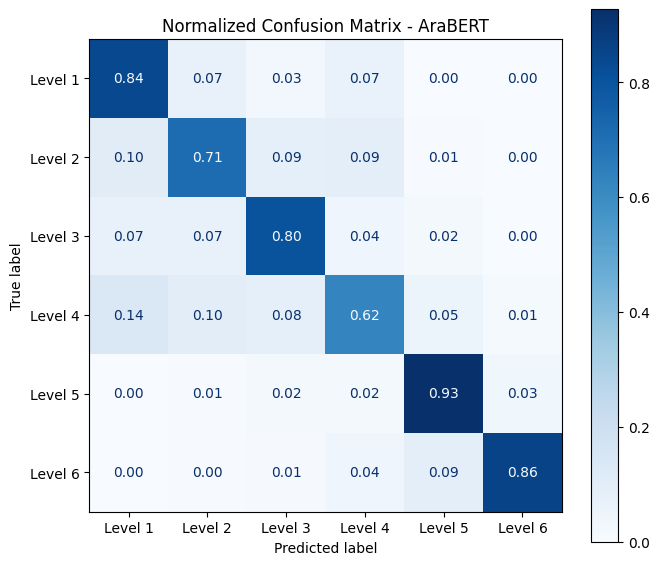

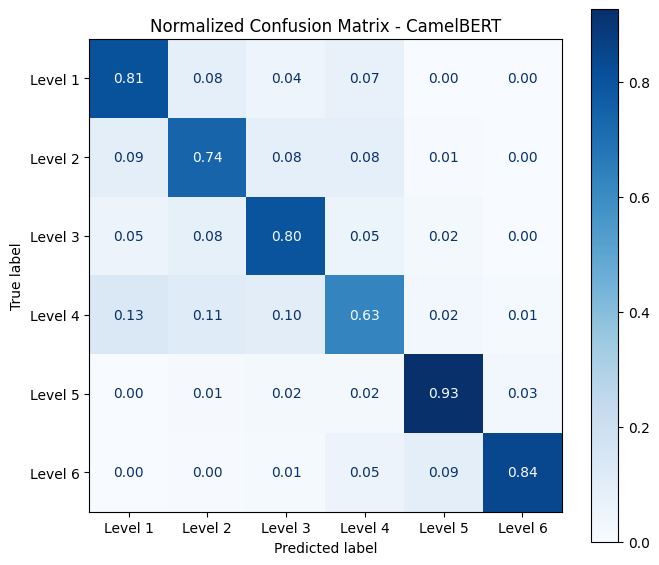

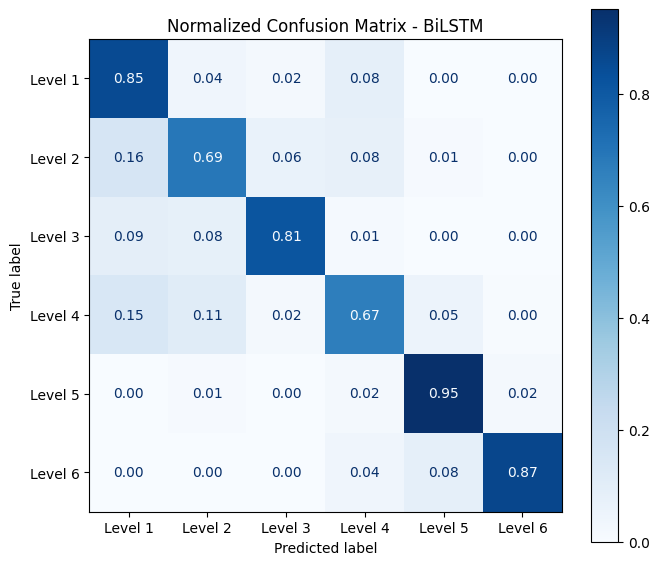

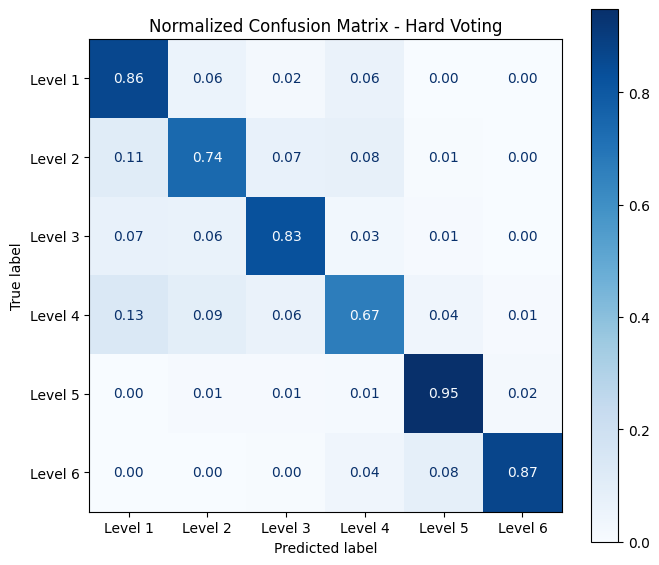

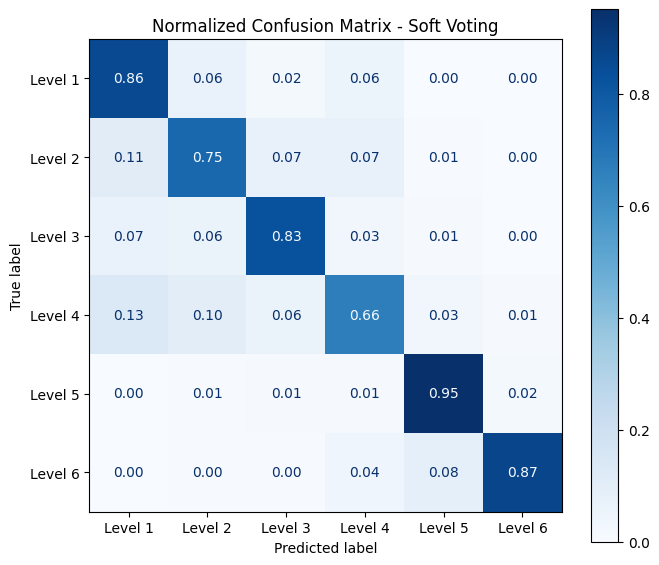

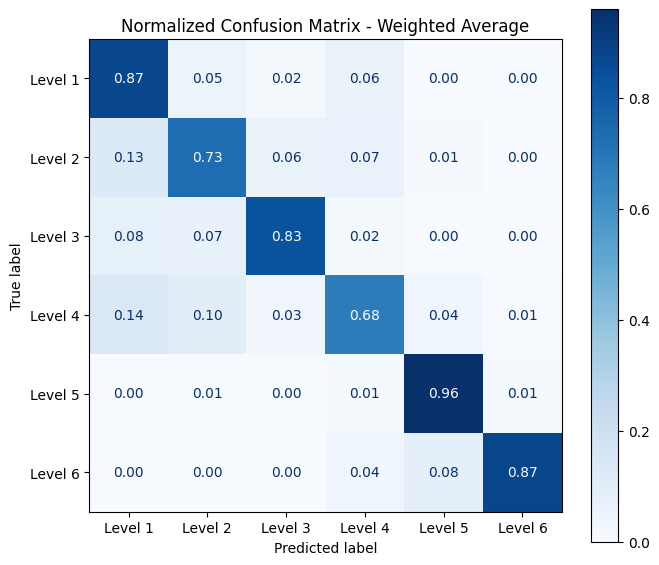

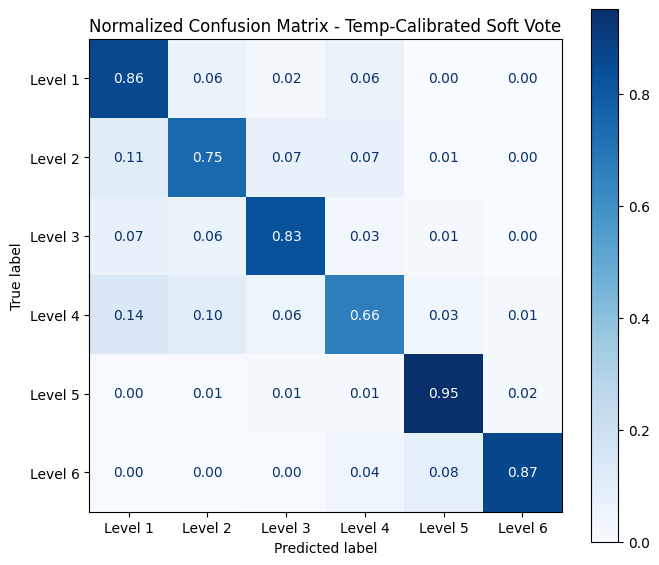

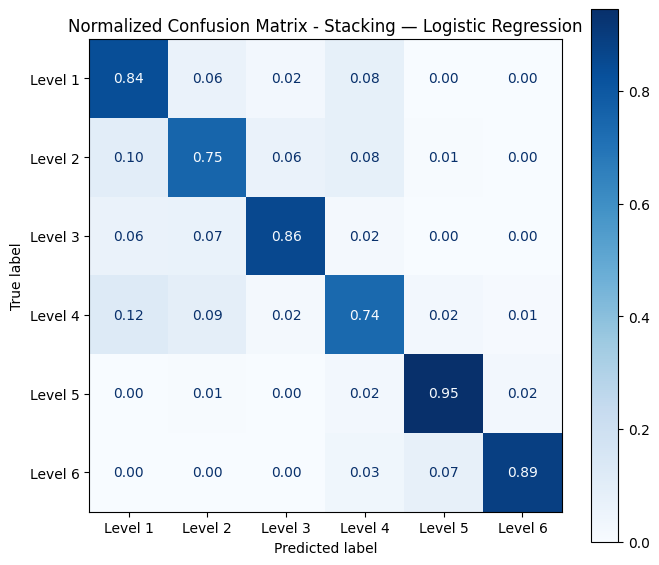

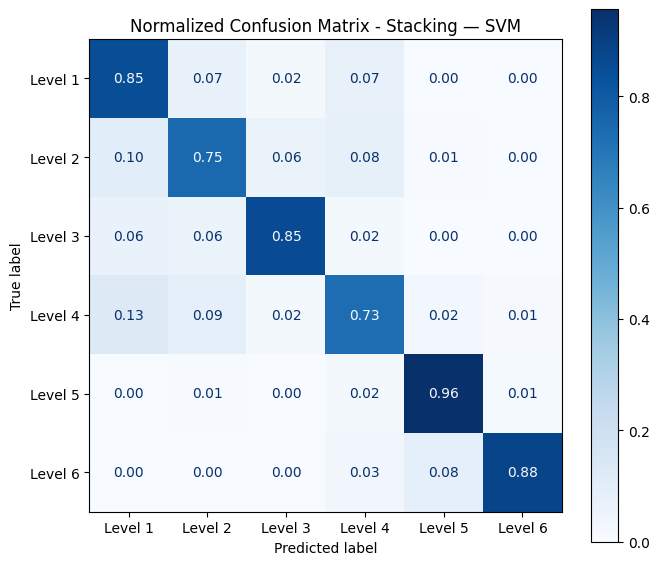

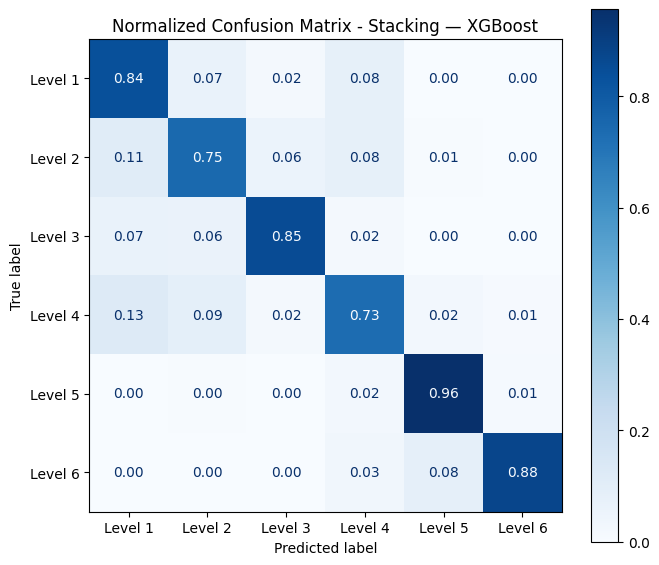

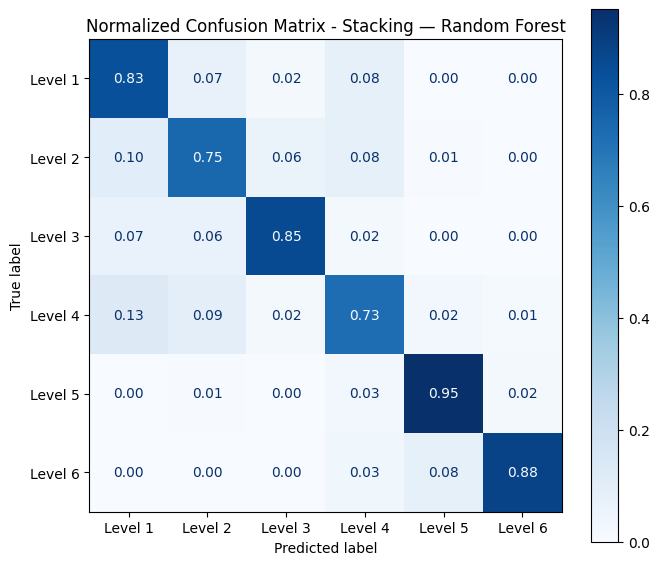

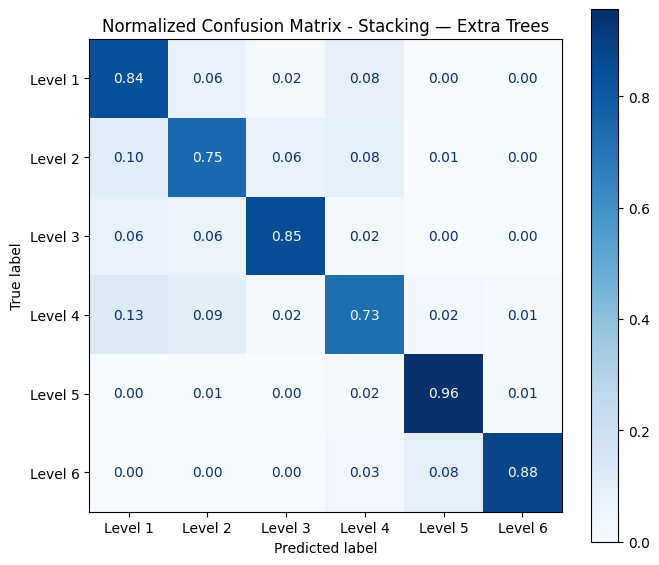

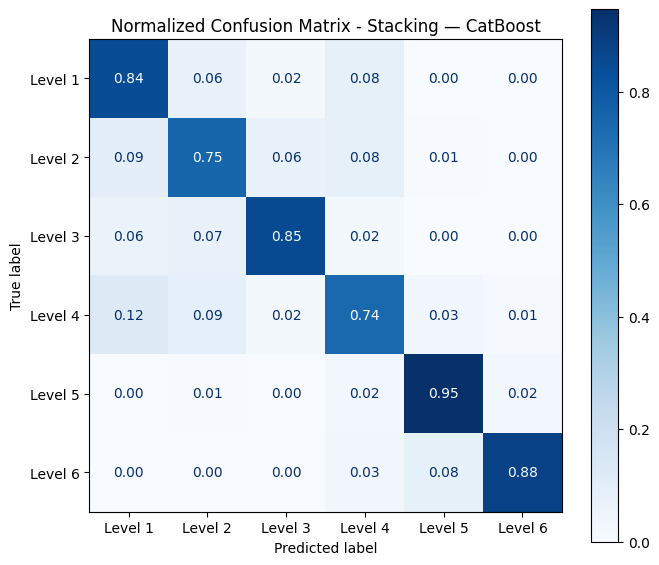

In [14]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — CONFUSION MATRICES
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 4 — Confusion Matrices (Normalized)")
print("=" * 65)

def plot_confusion_matrix_normalized(y_true, y_pred, title_suffix="",
                                      normalize="true", cmap="Blues"):
    cm   = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"Level {i+1}" for i in range(6)]
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.show()

# Base models first, then all ensemble methods
all_cm_models = {
    # ── Base models ───────────────────────────────────────────
    "AraBERT":                          preds_a,
    "CamelBERT":                        preds_c,
    "BiLSTM":                           preds_b,
    # ── Non-stacking ──────────────────────────────────────────
    "Hard Voting":                      preds_hard,
    "Soft Voting":                      preds_soft,
    "Weighted Average":                 preds_wgrid,
    "Temp-Calibrated Soft Vote":        preds_tempcal,
    # ── Stacking (best per family) ────────────────────────────
    **stacking_preds,
}

for model_name, preds in all_cm_models.items():
    plot_confusion_matrix_normalized(y_stack, preds, title_suffix=model_name)

In [15]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 — CLASSIFICATION REPORTS 
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  SECTION 5 — Classification Reports")
print("=" * 65)

for model_name, preds in all_cm_models.items():
    m = get_metrics(y_stack, preds)
    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"  Accuracy: {m['Accuracy']:.4f}  |  "
          f"Weighted F1: {m['Weighted F1']:.4f}  |  "
          f"QWK: {m['QWK']:.4f}")
    print(f"{'='*65}")
    print(classification_report(y_stack, preds, target_names=LEVELS, digits=4))


  SECTION 5 — Classification Reports

  AraBERT
  Accuracy: 0.7955  |  Weighted F1: 0.7945  |  QWK: 0.8851
              precision    recall  f1-score   support

     Level 1     0.7387    0.8374    0.7849      1519
     Level 2     0.7550    0.7120    0.7329      1528
     Level 3     0.7688    0.8012    0.7847      1353
     Level 4     0.6983    0.6249    0.6596      1437
     Level 5     0.8517    0.9275    0.8880      1530
     Level 6     0.9500    0.8571    0.9012      1617

    accuracy                         0.7955      8984
   macro avg     0.7937    0.7934    0.7919      8984
weighted avg     0.7968    0.7955    0.7945      8984


  CamelBERT
  Accuracy: 0.7915  |  Weighted F1: 0.7913  |  QWK: 0.8801
              precision    recall  f1-score   support

     Level 1     0.7512    0.8071    0.7782      1519
     Level 2     0.7350    0.7389    0.7369      1528
     Level 3     0.7384    0.7967    0.7664      1353
     Level 4     0.6873    0.6256    0.6550      1437
     L

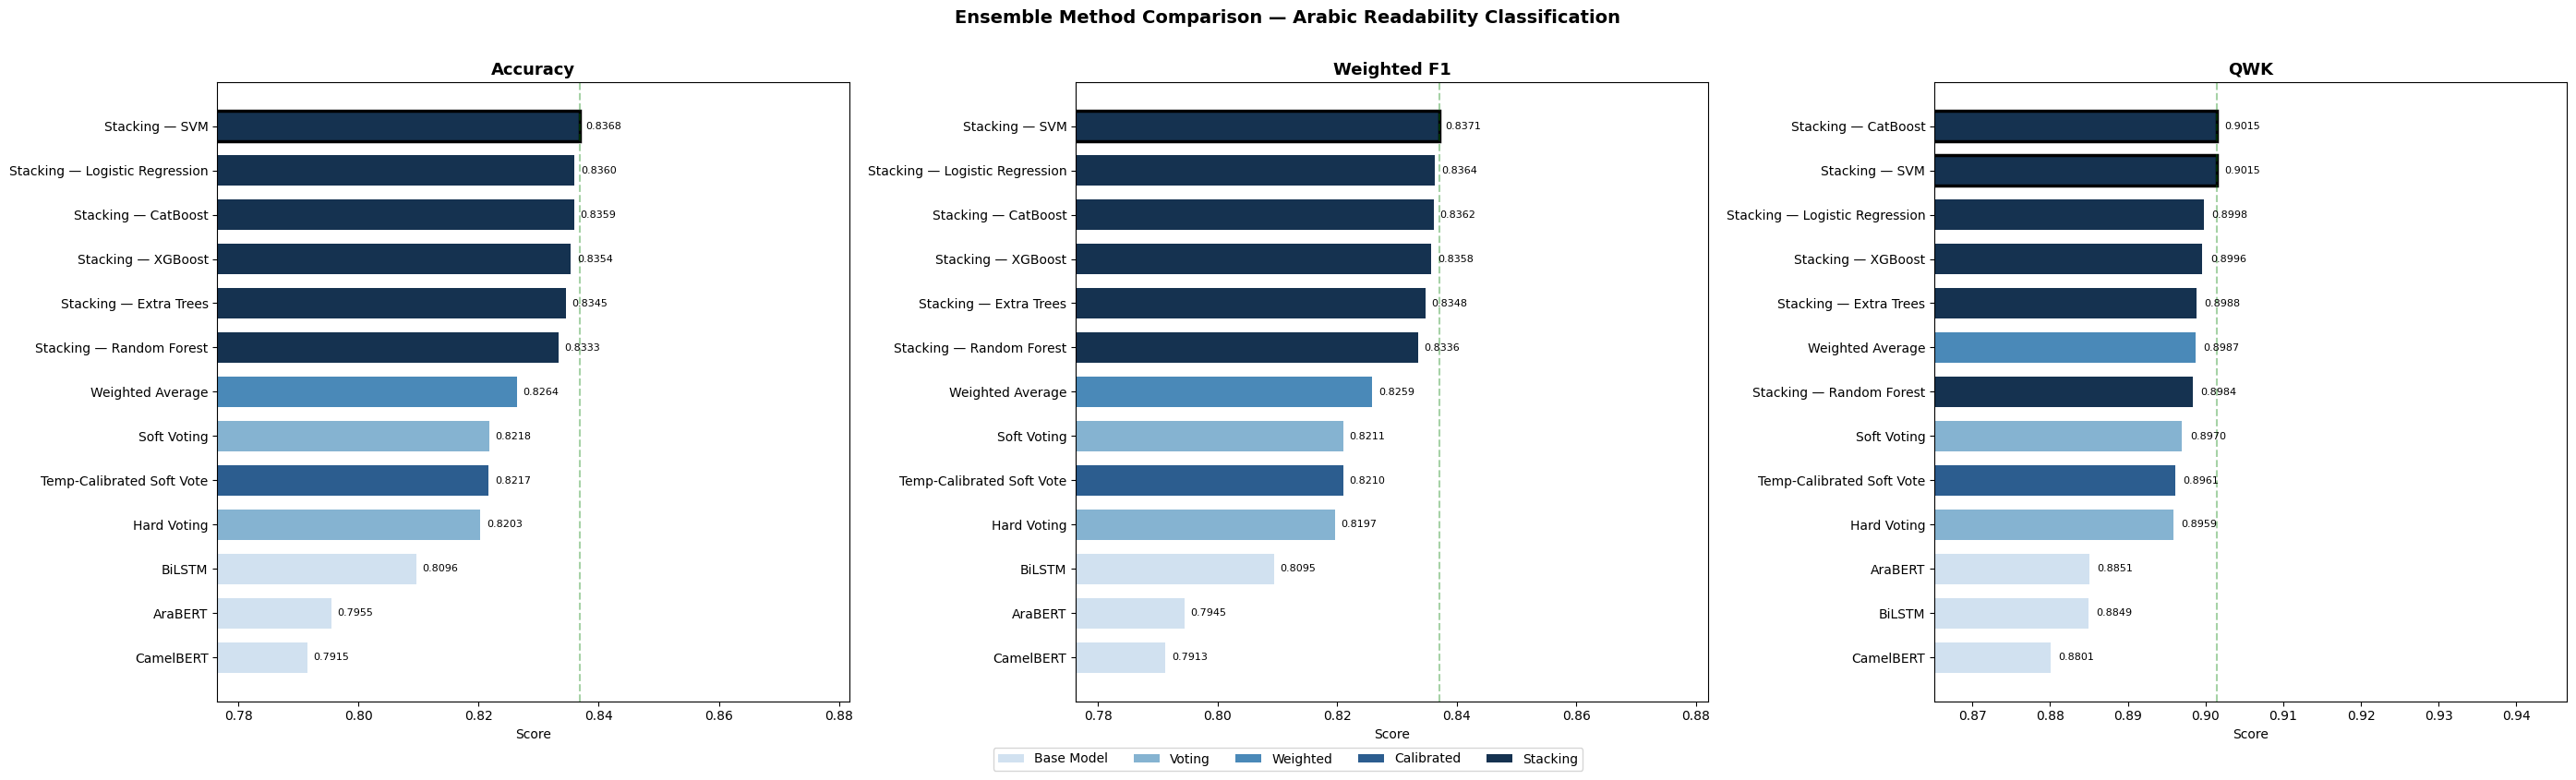

Saved → /kaggle/working/ensemble_final/ensemble_comparison_chart.png


In [16]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — COMPARISON BAR CHART
# ─────────────────────────────────────────────────────────────
type_colors = {
    "Base Model":  "#D1E1F0",  # Very Light Blue
    "Voting":      "#85B3D1",  # Soft Sky Blue
    "Weighted":    "#4A89B8",  # Medium Steel Blue
    "Calibrated":  "#2C5D8F",  # Deep Ocean Blue
    "Stacking":    "#153250",  # Dark Navy Blue
}

fig, axes = plt.subplots(1, 3, figsize=(28, max(8, len(summary) * 0.55)))
for ax, metric in zip(axes, ["Accuracy", "Weighted F1", "QWK"]):
    sorted_df  = summary.sort_values(metric, ascending=True)
    bar_colors = [type_colors[t] for t in sorted_df["Type"]]
    bars = ax.barh(sorted_df["Model"], sorted_df[metric],
                    color=bar_colors, height=0.7)

    best_val = sorted_df[metric].max()
    for bar, val in zip(bars, sorted_df[metric]):
        if val == best_val:
            bar.set_edgecolor("black")
            bar.set_linewidth(2.5)
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

    ax.set_xlim(sorted_df[metric].min() - 0.015, best_val + 0.045)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlabel("Score")
    ax.axvline(best_val, color="green", linestyle="--", alpha=0.35)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colors.items()
                   if t in summary["Type"].values]
fig.legend(handles=legend_elements, loc="lower center", ncol=5,
           fontsize=10, bbox_to_anchor=(0.5, -0.03))
plt.suptitle("Ensemble Method Comparison — Arabic Readability Classification",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/ensemble_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/ensemble_comparison_chart.png")

Best stacking model: Stacking — SVM
Total test samples: 8984
  AraBERT                                  errors: 1837 (20.4%)
  CamelBERT                                errors: 1873 (20.8%)
  BiLSTM                                   errors: 1711 (19.0%)
  Hard Voting                              errors: 1614 (18.0%)
  Soft Voting                              errors: 1601 (17.8%)
  Weighted Average                         errors: 1560 (17.4%)
  Stacking — SVM                           errors: 1466 (16.3%)

  ANALYSIS 1 — Confusion Matrices


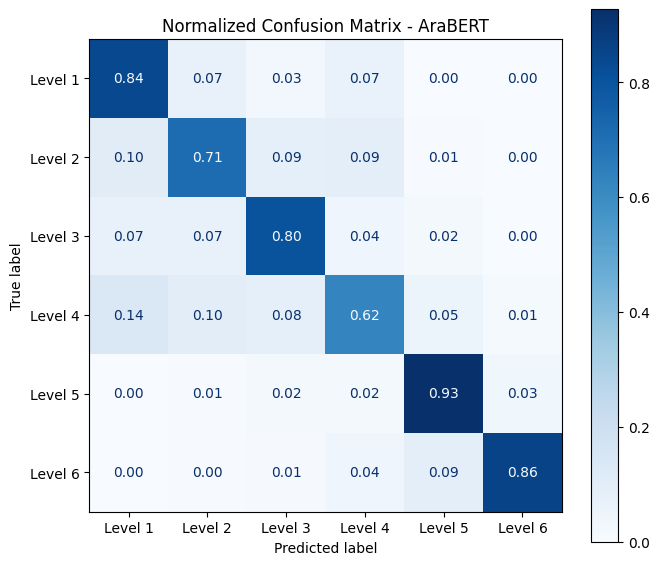

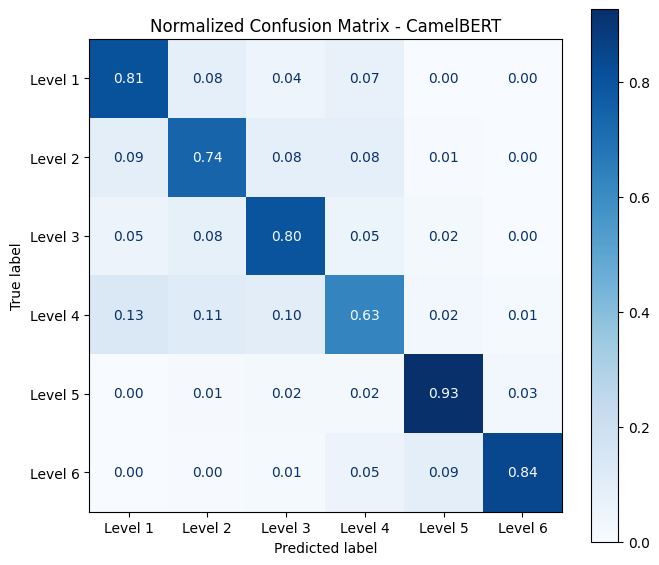

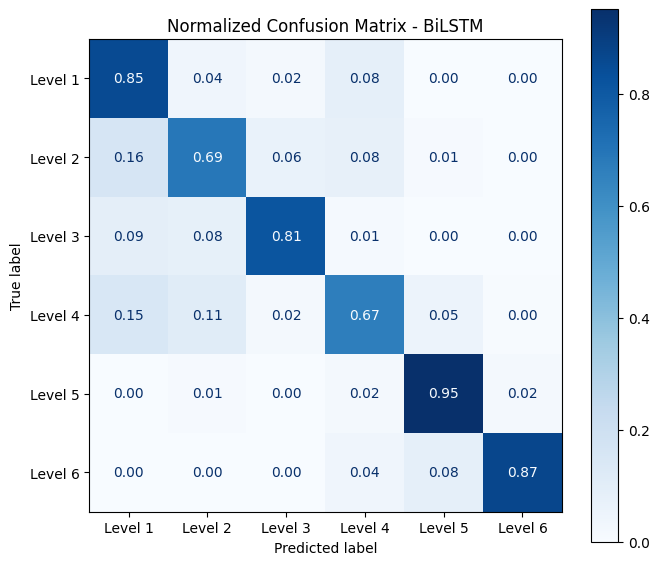

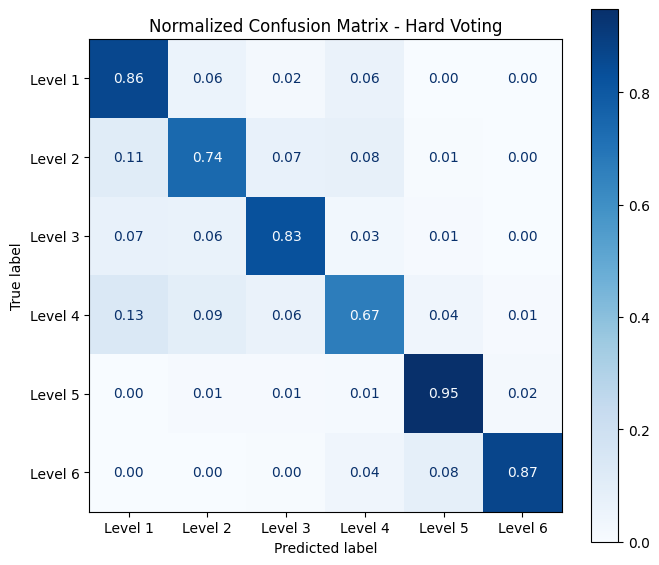

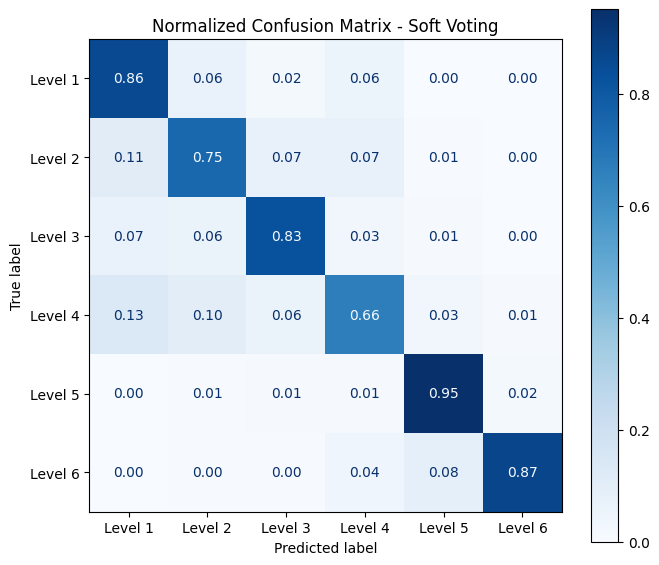

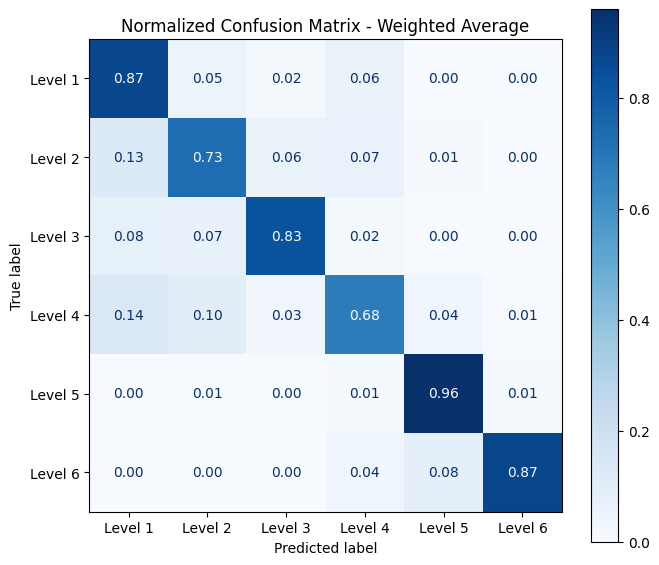

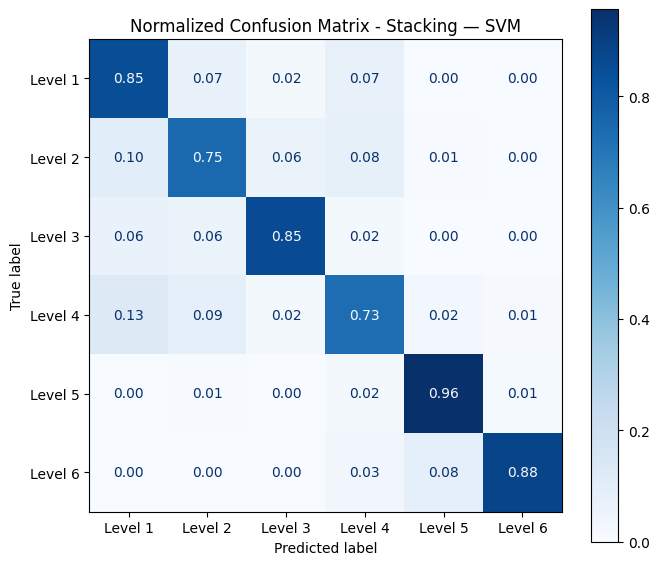


  ANALYSIS 2 — Classification Reports

  AraBERT
  Accuracy: 0.7955  |  Weighted F1: 0.7945  |  QWK: 0.8851
              precision    recall  f1-score   support

     Level 1     0.7387    0.8374    0.7849      1519
     Level 2     0.7550    0.7120    0.7329      1528
     Level 3     0.7688    0.8012    0.7847      1353
     Level 4     0.6983    0.6249    0.6596      1437
     Level 5     0.8517    0.9275    0.8880      1530
     Level 6     0.9500    0.8571    0.9012      1617

    accuracy                         0.7955      8984
   macro avg     0.7937    0.7934    0.7919      8984
weighted avg     0.7968    0.7955    0.7945      8984


  CamelBERT
  Accuracy: 0.7915  |  Weighted F1: 0.7913  |  QWK: 0.8801
              precision    recall  f1-score   support

     Level 1     0.7512    0.8071    0.7782      1519
     Level 2     0.7350    0.7389    0.7369      1528
     Level 3     0.7384    0.7967    0.7664      1353
     Level 4     0.6873    0.6256    0.6550      1437
     

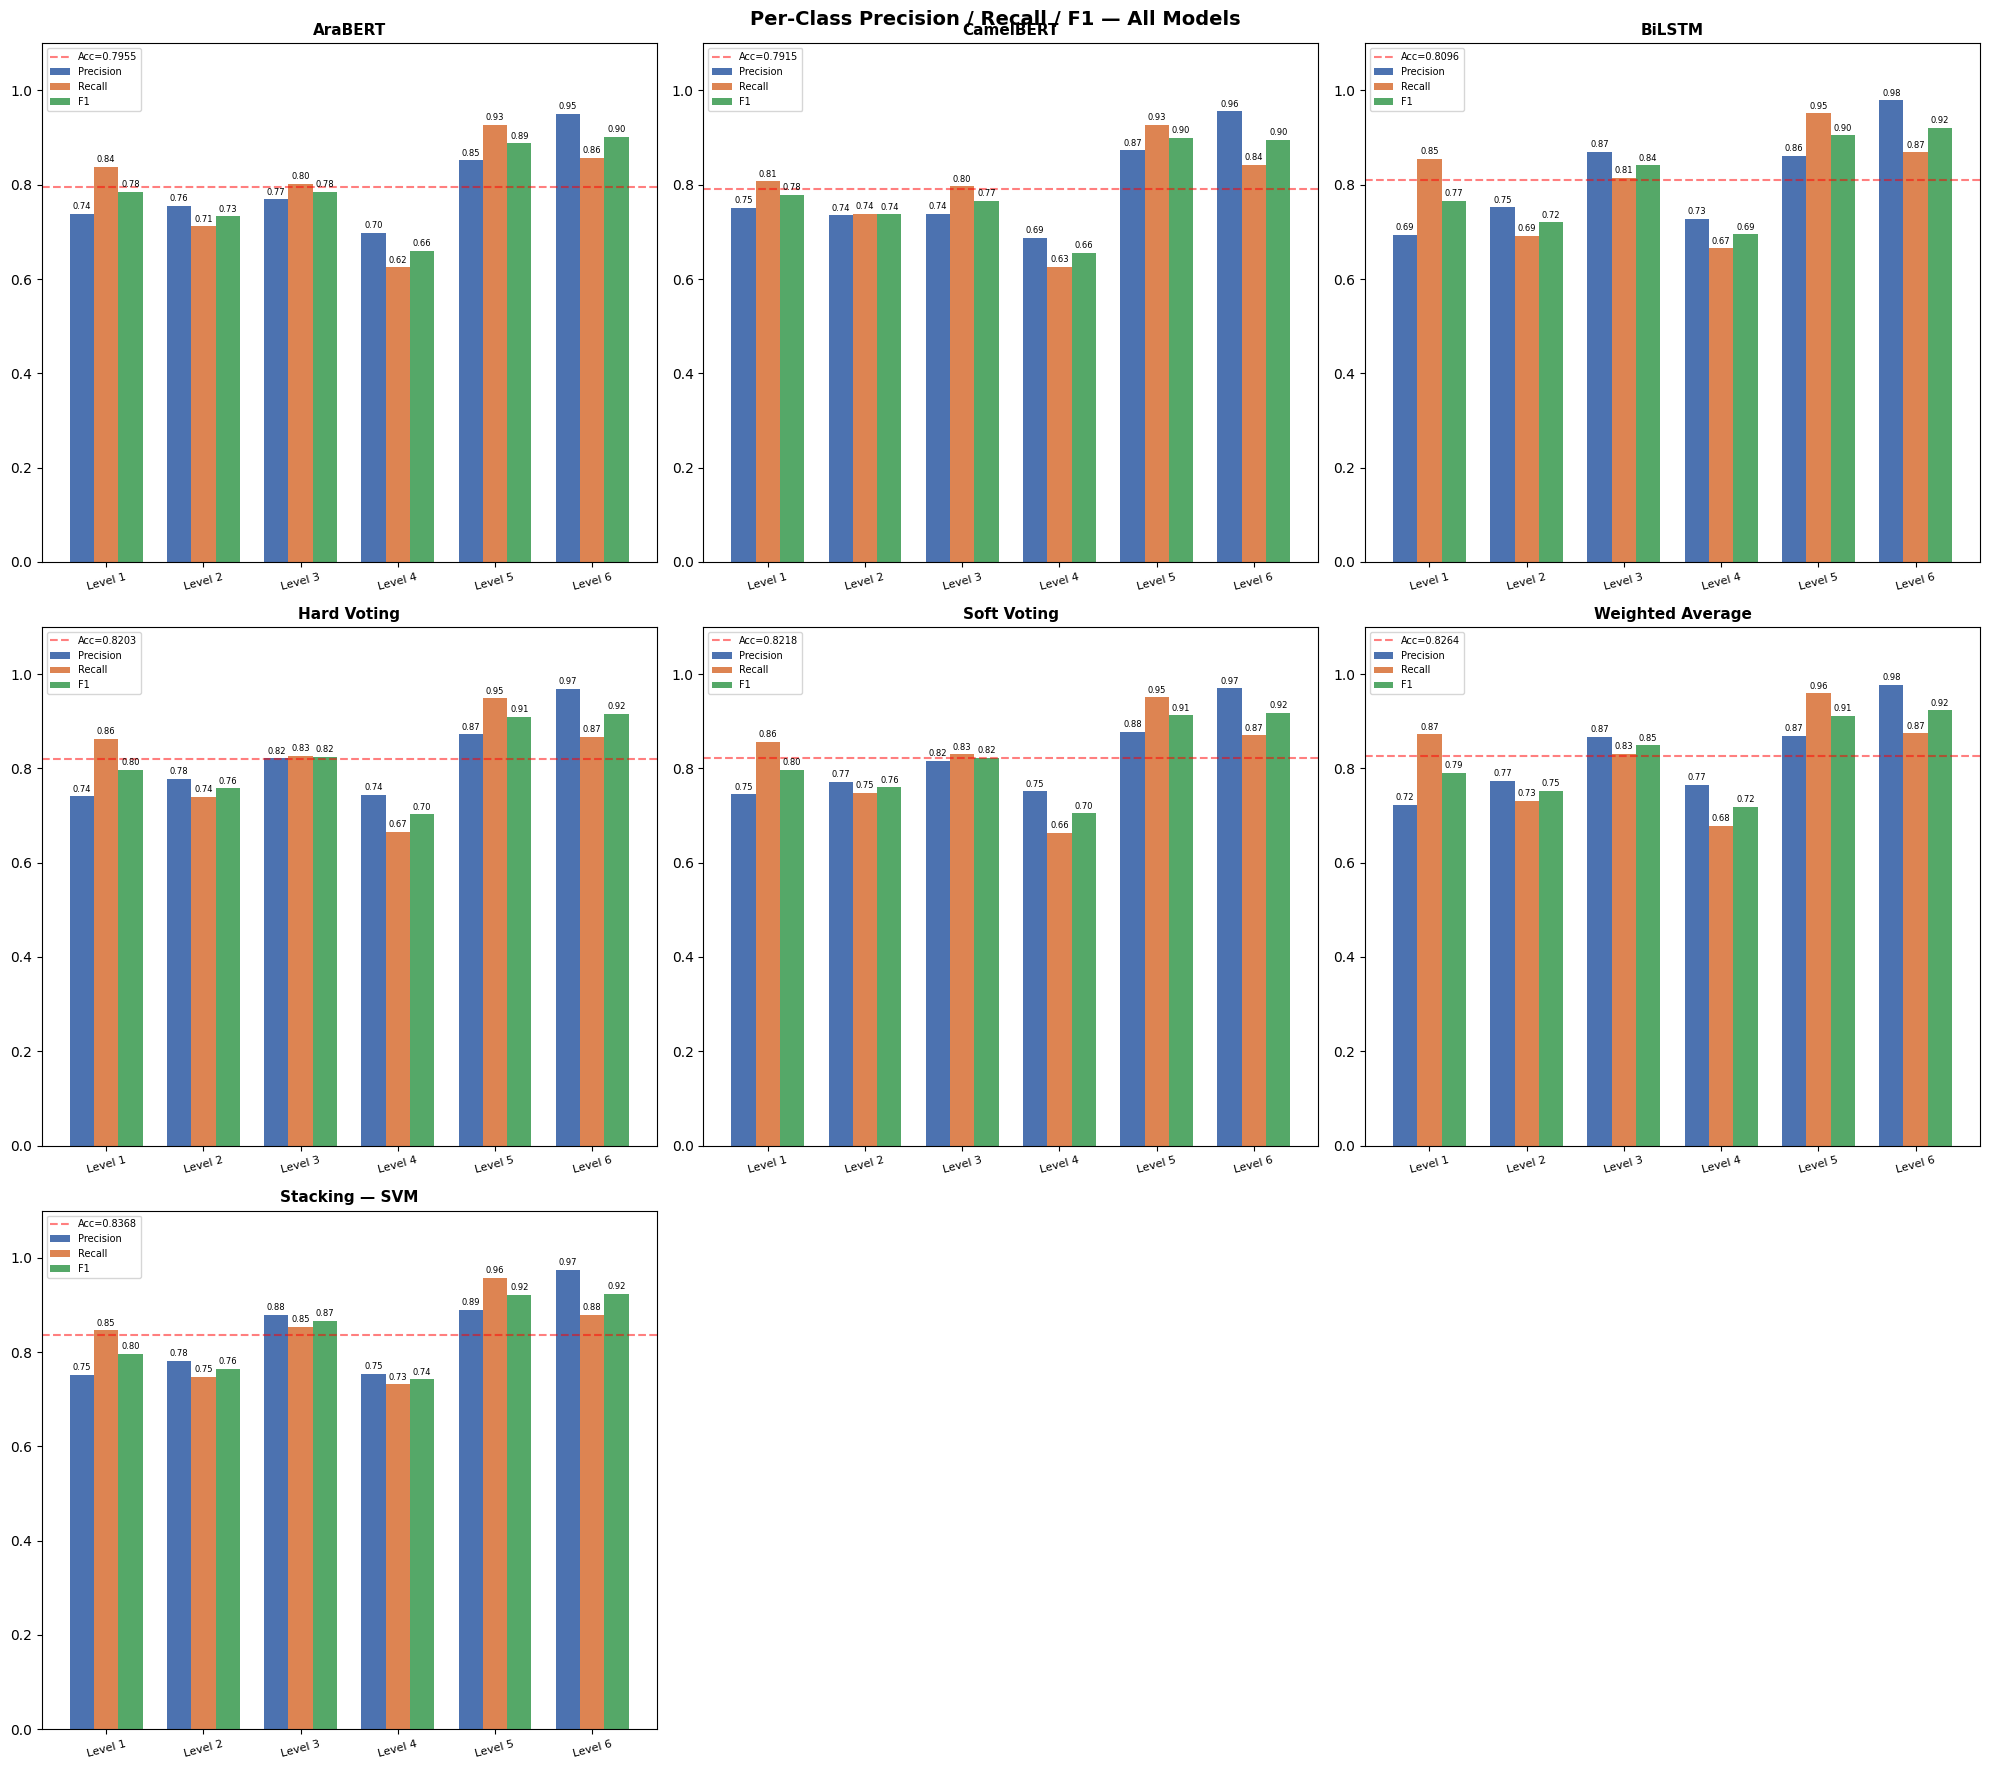


  ANALYSIS 4 — Ordinal Error Analysis

AraBERT:
  Adjacent (dist=1):     51.8%
  Non-adjacent (dist>1): 48.2%
  Over-predicted:        40.9%
  Under-predicted:       59.1%

CamelBERT:
  Adjacent (dist=1):     50.6%
  Non-adjacent (dist>1): 49.4%
  Over-predicted:        39.5%
  Under-predicted:       60.5%

BiLSTM:
  Adjacent (dist=1):     48.4%
  Non-adjacent (dist>1): 51.6%
  Over-predicted:        33.8%
  Under-predicted:       66.2%

Hard Voting:
  Adjacent (dist=1):     50.1%
  Non-adjacent (dist>1): 49.9%
  Over-predicted:        36.5%
  Under-predicted:       63.5%

Soft Voting:
  Adjacent (dist=1):     50.4%
  Non-adjacent (dist>1): 49.6%
  Over-predicted:        36.7%
  Under-predicted:       63.3%

Weighted Average:
  Adjacent (dist=1):     49.9%
  Non-adjacent (dist>1): 50.1%
  Over-predicted:        33.8%
  Under-predicted:       66.2%

Stacking — SVM:
  Adjacent (dist=1):     48.7%
  Non-adjacent (dist>1): 51.3%
  Over-predicted:        38.5%
  Under-predicted:       61.5

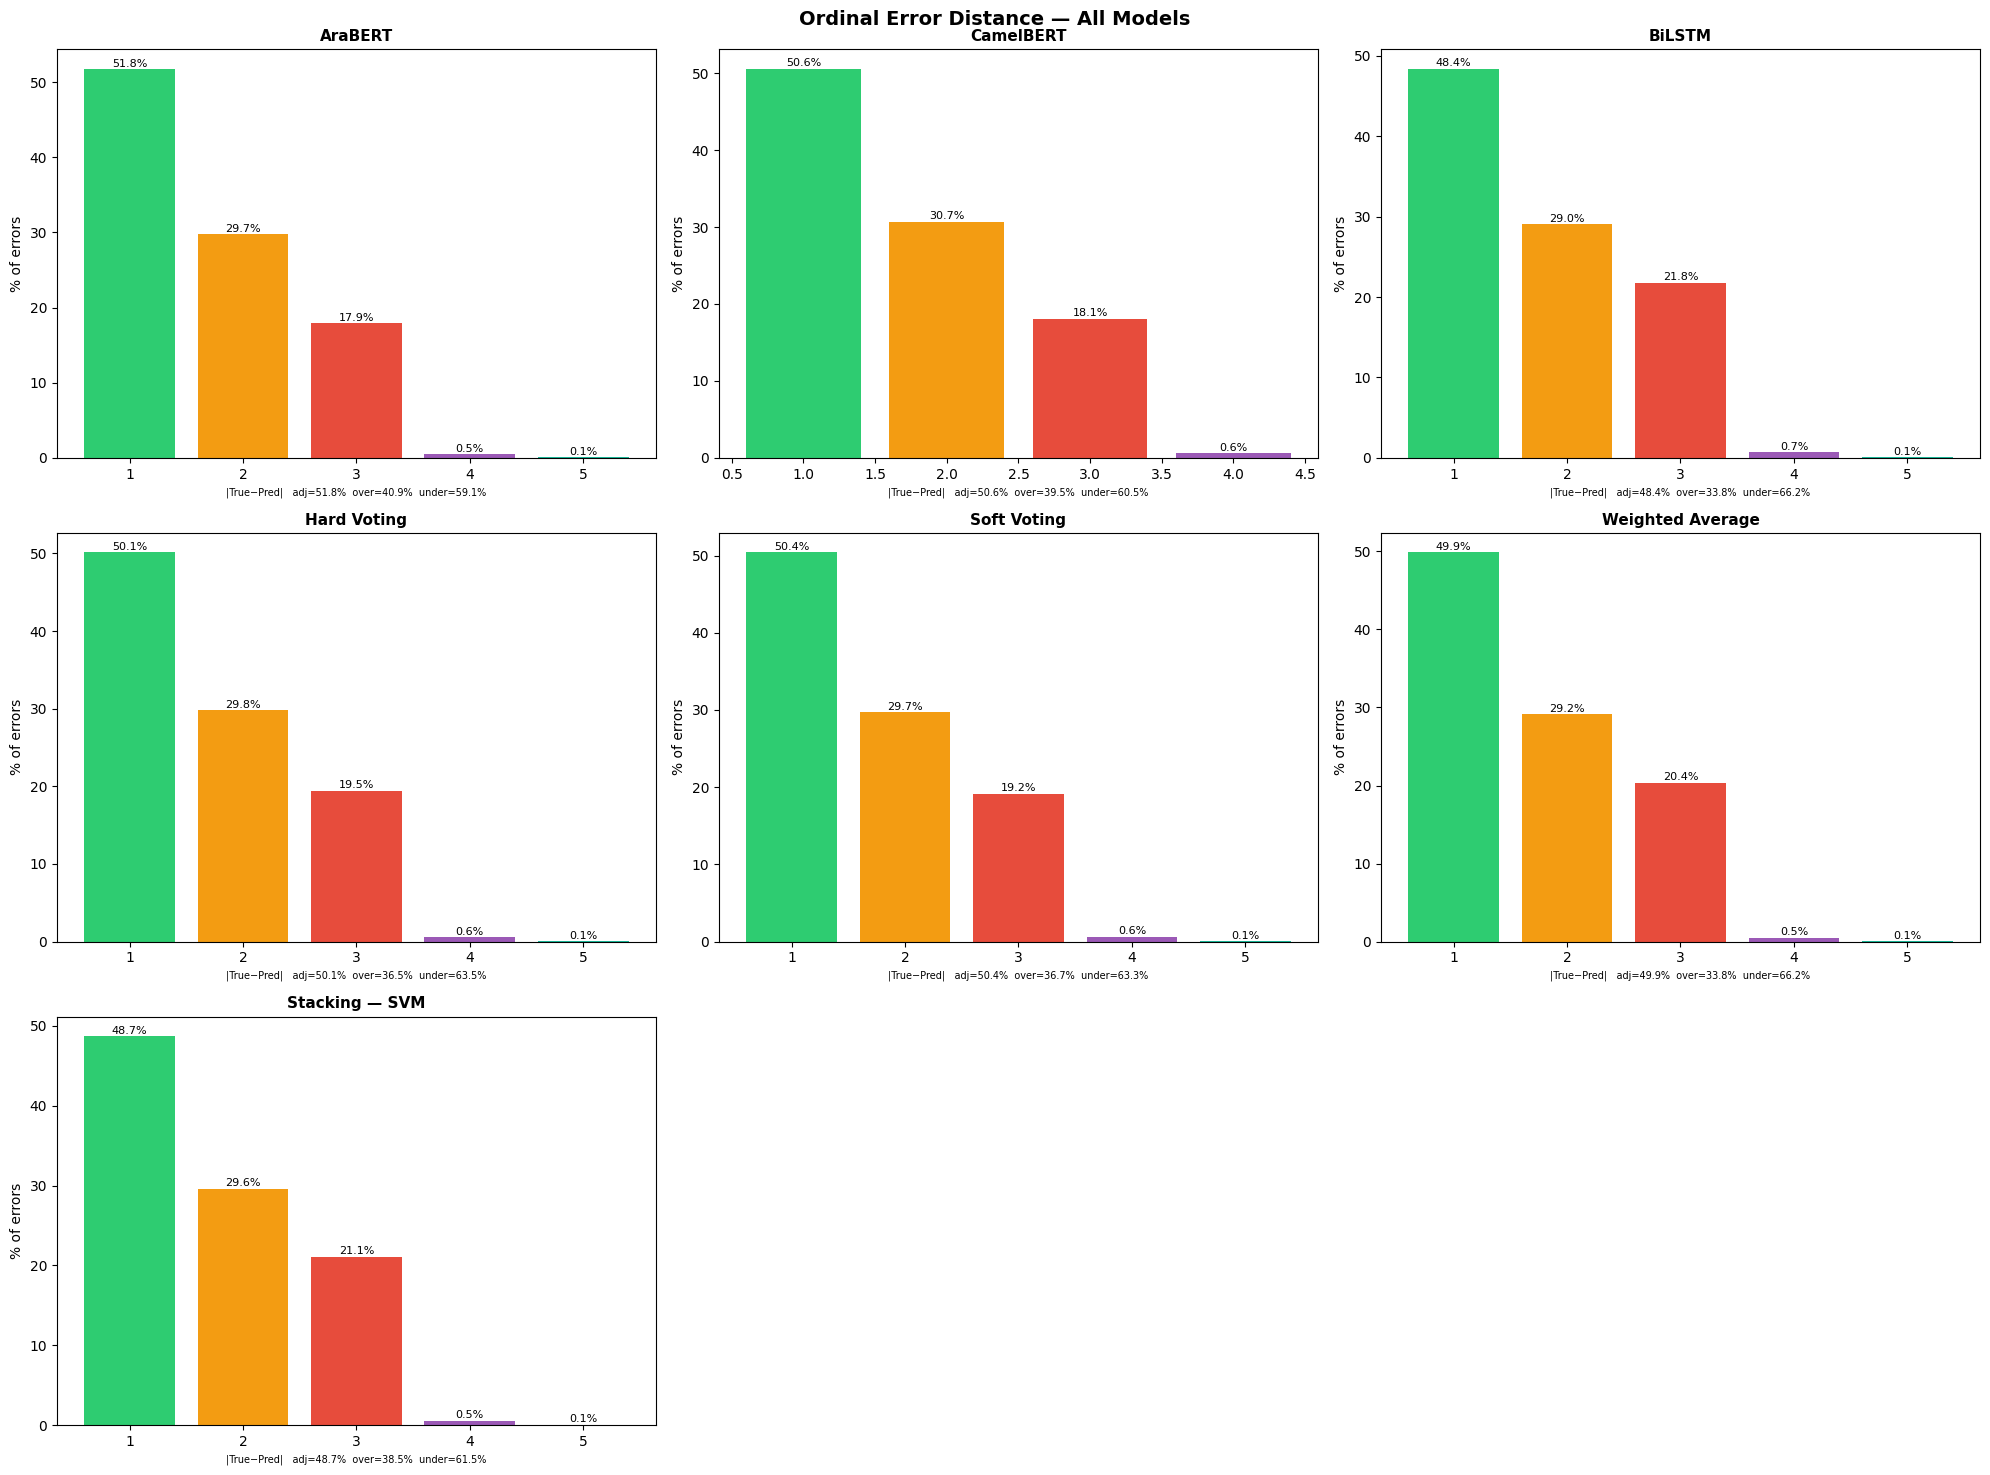


  ANALYSIS 5 — Confidence Calibration (Soft Voting)


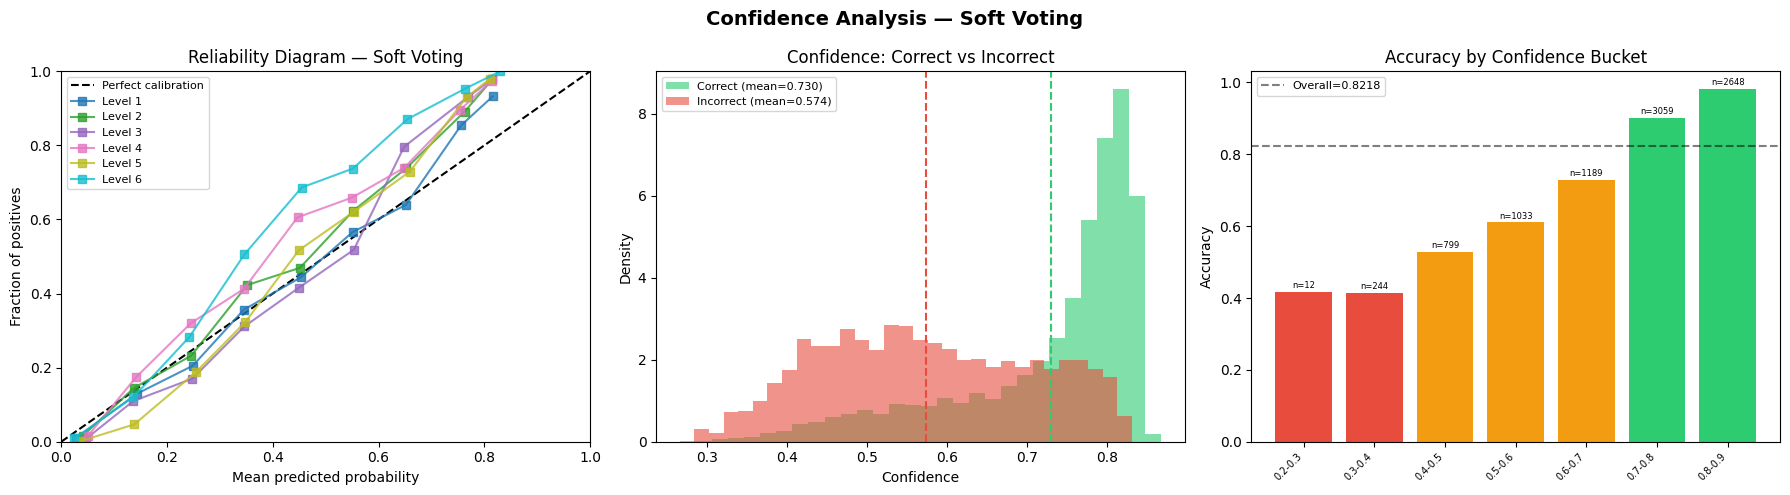

  Mean confidence correct:   0.7298
  Mean confidence incorrect: 0.5742
  Confidence gap:            0.1555

  ANALYSIS 6 — Model Agreement


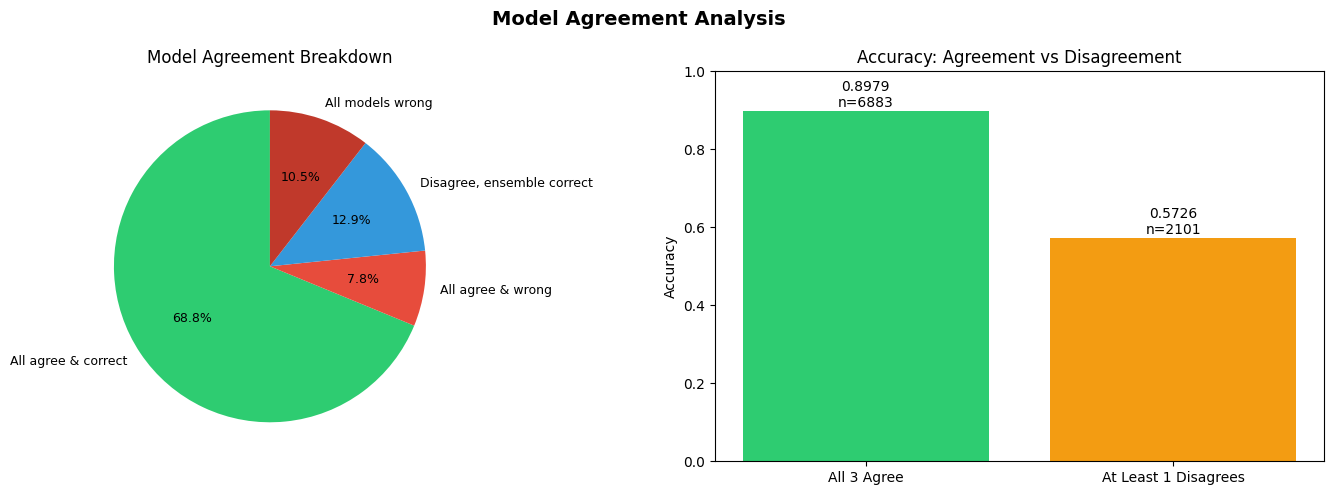

  All 3 agree:            6883 (76.6%)
    → Correct:            6180 (89.8% of unanimous)
    → Wrong:              703 (10.2% of unanimous)
  At least 1 disagrees:   2101 (23.4%)
  All 3 wrong:            943 (10.5%)

  ANALYSIS 7 — Hard Examples (Stacking — SVM)


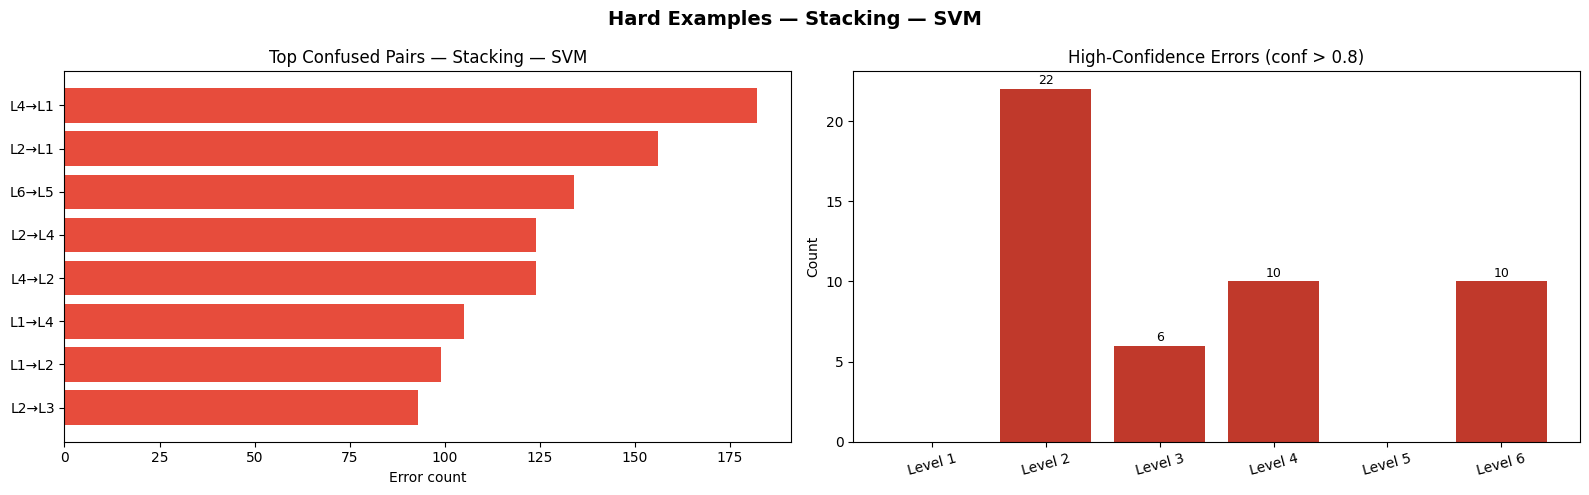


Top 20 Hard Errors — Stacking — SVM (most confidently wrong):
  #     True  Pred   Conf  Dist  Text
  ----------------------------------------------------------------------
  1    L2→L1    0.831     1   احمد ماهر عبد الفتاح
  2    L2→L1    0.828     1   ثالثا اختار الاجابة الصحيحة
  3    L2→L3    0.828     1   وبما انه مصروفك الخاص فانت حرة في انفاقه كما تريدين
  4    L3→L1    0.825     2   السمك يسبح في الماء بسرعة وسهولة
  5    L4→L1    0.823     3   هنا كمال الدين حسين محمد اسيوط مصر
  6    L2→L3    0.822     1   لا يجوز للمسلم ان ينفق وقته فيما يضره او فيما لا يعود ع...
  7    L2→L1    0.822     1   هل استطيع ان اعود للتدريب
  8    L2→L1    0.822     1   كيف يتواصل الناس مع بعضهم بعضا اليوم
  9    L2→L1    0.819     1   الاصدقاء يلعبون العابا مسلية في حديقة الالعاب المفتوحة
  10   L2→L1    0.819     1   الام تطهو طعاما للعايلة معا
  11   L4→L1    0.819     3   اتامل الالوان والابعاد في الصورتين
  12   L3→L1    0.818     2   عدد الوان علم بلادي ثلاثة ا صح ب خطا
  13   L3→L1    0.81

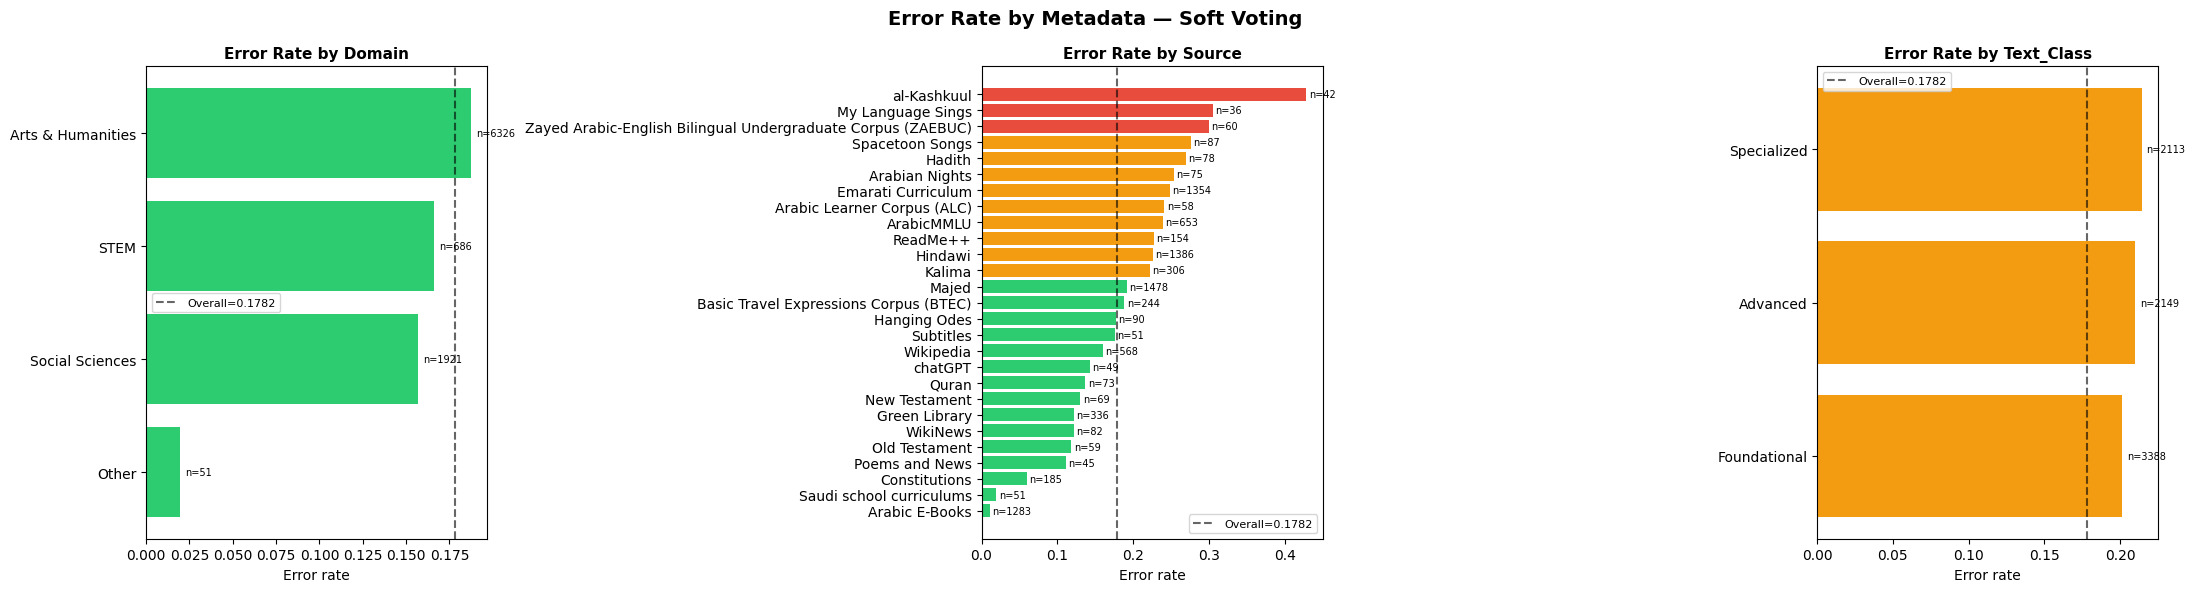


Top 3 error-prone categories (min 15 samples) — Soft Voting:
  Domain:
    Arts & Humanities              error=0.1873  n=6326
    STEM                           error=0.1662  n=686
    Social Sciences                error=0.1567  n=1921
  Source:
    al-Kashkuul                    error=0.4286  n=42
    My Language Sings              error=0.3056  n=36
    Zayed Arabic-English Bilingual Undergraduate Corpus (ZAEBUC) error=0.3000  n=60
  Text_Class:
    Specialized                    error=0.2144  n=2113
    Advanced                       error=0.2099  n=2149
    Foundational                   error=0.2013  n=3388

  ERROR ANALYSIS COMPLETE
  Models analyzed:   7
  Best stacking:     Stacking — SVM
  Error CSV:         /kaggle/working/ensemble_errors.csv
  Plots saved to:    /kaggle/working/error_analysis/
    01_perclass_metrics.png
    02_ordinal_errors.png
    03_confidence.png
    04_model_agreement.png
    05_hard_examples.png
    06_metadata_errors.png


In [17]:
# ============================================================
# CELL 12 — Comprehensive Error Analysis
# ============================================================
# Models analyzed (7 total):
#   Base:     AraBERT, CamelBERT, BiLSTM
#   Voting:   Hard Voting, Soft Voting
#   Weighted: Weighted Average
#   Stacking: Best stacking model
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay,
                              precision_recall_fscore_support)
from sklearn.calibration import calibration_curve

OUT_DIR = "/kaggle/working/error_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

labels_arr = np.array(labels)
LEVELS     = [f"Level {i+1}" for i in range(6)]

# ── Identify best stacking model from summary table ────────────────────────
stacking_rows = summary[summary["Type"] == "Stacking"]
best_stack_name  = stacking_rows.loc[stacking_rows["QWK"].idxmax(), "Model"]
best_stack_preds = stacking_preds[best_stack_name]
print(f"Best stacking model: {best_stack_name}")

# ── 7 models for analysis ─────────────────────────────────────────────────
ANALYSIS_MODELS = {
    "AraBERT":          preds_a,
    "CamelBERT":        preds_c,
    "BiLSTM":           preds_b,
    "Hard Voting":      preds_hard,
    "Soft Voting":      preds_soft,
    "Weighted Average": preds_wgrid,
    best_stack_name:    best_stack_preds,
}

# ── Build master analysis dataframe ───────────────────────────────────────
analysis_df = test_df.copy()
analysis_df["true_label"] = labels_arr

soft_avg_probs = (probs_arabert + probs_camelbert + probs_bilstm) / 3
analysis_df["confidence_soft"] = soft_avg_probs.max(axis=1)

for name, preds in ANALYSIS_MODELS.items():
    col = name.lower().replace(" ", "_").replace("—", "").strip()
    analysis_df[f"pred_{col}"]    = preds
    analysis_df[f"correct_{col}"] = (preds == labels_arr)
    analysis_df[f"dist_{col}"]    = np.abs(preds - labels_arr)

raw_test = test_valid["train"].to_pandas()

print(f"Total test samples: {len(analysis_df)}")
for name, preds in ANALYSIS_MODELS.items():
    err = (preds != labels_arr).sum()
    print(f"  {name:<40} errors: {err} ({err/len(labels_arr)*100:.1f}%)")


# ─────────────────────────────────────────────────────────────
# SHARED CM FUNCTION (matches your notebook style)
# ─────────────────────────────────────────────────────────────
def plot_confusion_matrix_normalized(y_true, y_pred, title_suffix="",
                                      normalize="true", cmap="Blues"):
    cm   = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"Level {i+1}" for i in range(6)]
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# ANALYSIS 1 — Confusion Matrices (all 7 models)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 1 — Confusion Matrices")
print("="*60)

for name, preds in ANALYSIS_MODELS.items():
    plot_confusion_matrix_normalized(labels_arr, preds, title_suffix=name)


# ─────────────────────────────────────────────────────────────
# ANALYSIS 2 — Classification Reports (4 decimal places)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 2 — Classification Reports")
print("="*60)

for name, preds in ANALYSIS_MODELS.items():
    acc = accuracy_score(labels_arr, preds)
    f1  = f1_score(labels_arr, preds, average="weighted")
    qwk = cohen_kappa_score(labels_arr, preds, weights="quadratic")
    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"  Accuracy: {acc:.4f}  |  Weighted F1: {f1:.4f}  |  QWK: {qwk:.4f}")
    print(f"{'='*65}")
    print(classification_report(labels_arr, preds, target_names=LEVELS, digits=4))


# ─────────────────────────────────────────────────────────────
# ANALYSIS 3 — Per-Class Metrics Bar Chart (all 7 models)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 3 — Per-Class Metrics")
print("="*60)

n_models = len(ANALYSIS_MODELS)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(20, 6 * n_rows))
axes = axes.flatten()

for idx, (name, preds) in enumerate(ANALYSIS_MODELS.items()):
    ax   = axes[idx]
    acc  = accuracy_score(labels_arr, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels_arr, preds, average=None, labels=list(range(6)))
    x = np.arange(6); w = 0.25
    ax.bar(x - w, prec, w, label="Precision", color="#4C72B0")
    ax.bar(x,     rec,  w, label="Recall",    color="#DD8452")
    ax.bar(x + w, f1,   w, label="F1",        color="#55A868")
    ax.set_xticks(x); ax.set_xticklabels(LEVELS, rotation=15, fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.axhline(acc, color="red", linestyle="--", alpha=0.5,
               label=f"Acc={acc:.4f}")
    ax.legend(fontsize=7)
    for i in range(6):
        ax.text(i - w, prec[i] + 0.01, f"{prec[i]:.2f}", ha="center", fontsize=6)
        ax.text(i,     rec[i]  + 0.01, f"{rec[i]:.2f}",  ha="center", fontsize=6)
        ax.text(i + w, f1[i]   + 0.01, f"{f1[i]:.2f}",   ha="center", fontsize=6)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Per-Class Precision / Recall / F1 — All Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_perclass_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────
# ANALYSIS 4 — Ordinal Error Analysis (all 7 models)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 4 — Ordinal Error Analysis")
print("="*60)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(20, 5 * n_rows))
axes = axes.flatten()

clrs = ["#2ecc71", "#f39c12", "#e74c3c", "#9b59b6", "#1abc9c"]

for idx, (name, preds) in enumerate(ANALYSIS_MODELS.items()):
    ax     = axes[idx]
    errors = labels_arr[preds != labels_arr]
    epreds = preds[preds != labels_arr]
    dists  = np.abs(epreds - errors)
    total  = len(dists)

    dist_counts = pd.Series(dists).value_counts().sort_index()
    ax.bar(dist_counts.index,
           dist_counts.values / total * 100,
           color=clrs[:len(dist_counts)])

    adj_pct  = (dists == 1).mean() * 100
    over_pct = (epreds > errors).mean() * 100
    for d, v in zip(dist_counts.index, dist_counts.values):
        ax.text(d, v/total*100 + 0.3,
                f"{v/total*100:.1f}%", ha="center", fontsize=8)

    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel(f"|True−Pred|   adj={adj_pct:.1f}%  "
                  f"over={over_pct:.1f}%  under={100-over_pct:.1f}%",
                  fontsize=7)
    ax.set_ylabel("% of errors")

    print(f"\n{name}:")
    print(f"  Adjacent (dist=1):     {adj_pct:.1f}%")
    print(f"  Non-adjacent (dist>1): {100-adj_pct:.1f}%")
    print(f"  Over-predicted:        {over_pct:.1f}%")
    print(f"  Under-predicted:       {100-over_pct:.1f}%")

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Ordinal Error Distance — All Models",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_ordinal_errors.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────
# ANALYSIS 5 — Confidence Analysis (Soft Voting as representative)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 5 — Confidence Calibration (Soft Voting)")
print("="*60)

correct_soft = preds_soft == labels_arr
conf_soft    = soft_avg_probs.max(axis=1)
mc = conf_soft[correct_soft].mean()
mi = conf_soft[~correct_soft].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reliability diagram
axes[0].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
colors = plt.cm.tab10(np.linspace(0, 1, 6))
for cls in range(6):
    try:
        fop, mpv = calibration_curve(
            (labels_arr == cls).astype(int),
            soft_avg_probs[:, cls], n_bins=10)
        axes[0].plot(mpv, fop, "s-", color=colors[cls],
                     label=LEVELS[cls], alpha=0.8)
    except Exception:
        pass
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Fraction of positives")
axes[0].set_title("Reliability Diagram — Soft Voting", fontsize=12)
axes[0].legend(fontsize=8); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Confidence: correct vs incorrect
axes[1].hist(conf_soft[correct_soft],  bins=30, alpha=0.6,
              color="#2ecc71", label=f"Correct (mean={mc:.3f})", density=True)
axes[1].hist(conf_soft[~correct_soft], bins=30, alpha=0.6,
              color="#e74c3c", label=f"Incorrect (mean={mi:.3f})", density=True)
axes[1].axvline(mc, color="#2ecc71", linestyle="--")
axes[1].axvline(mi, color="#e74c3c", linestyle="--")
axes[1].set_xlabel("Confidence"); axes[1].set_ylabel("Density")
axes[1].set_title("Confidence: Correct vs Incorrect", fontsize=12)
axes[1].legend(fontsize=8)

# Accuracy by confidence bucket
bins_c    = np.linspace(0, 1, 11)
bin_lbls  = [f"{b:.1f}-{b+0.1:.1f}" for b in bins_c[:-1]]
conf_df   = pd.DataFrame({"conf": conf_soft, "correct": correct_soft})
conf_df["bucket"] = pd.cut(conf_df["conf"], bins=bins_c, labels=bin_lbls)
bucket_stats = conf_df.groupby("bucket", observed=True)["correct"].agg(["mean", "count"])
bar_clrs = ["#e74c3c" if v < 0.5 else "#f39c12" if v < 0.75 else "#2ecc71"
             for v in bucket_stats["mean"]]
axes[2].bar(range(len(bucket_stats)), bucket_stats["mean"], color=bar_clrs)
axes[2].set_xticks(range(len(bucket_stats)))
axes[2].set_xticklabels(bucket_stats.index, rotation=45, ha="right", fontsize=7)
axes[2].axhline(accuracy_score(labels_arr, preds_soft), color="black",
                linestyle="--", alpha=0.5,
                label=f"Overall={accuracy_score(labels_arr, preds_soft):.4f}")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy by Confidence Bucket", fontsize=12)
axes[2].legend(fontsize=8)
for i, (av, cnt) in enumerate(zip(bucket_stats["mean"], bucket_stats["count"])):
    axes[2].text(i, av + 0.01, f"n={cnt}", ha="center", fontsize=6)

plt.suptitle("Confidence Analysis — Soft Voting", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_confidence.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Mean confidence correct:   {mc:.4f}")
print(f"  Mean confidence incorrect: {mi:.4f}")
print(f"  Confidence gap:            {mc - mi:.4f}")


# ─────────────────────────────────────────────────────────────
# ANALYSIS 6 — Model Agreement
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 6 — Model Agreement")
print("="*60)

all_agree     = ((preds_a == preds_c) & (preds_a == preds_b))
all_wrong     = ((preds_a != labels_arr) & (preds_c != labels_arr) & (preds_b != labels_arr))
correct_soft_ = (preds_soft == labels_arr)

total         = len(labels_arr)
n_agree       = all_agree.sum()
n_disagree    = (~all_agree).sum()
unani_correct = (all_agree &  correct_soft_).sum()
unani_wrong   = (all_agree & ~correct_soft_).sum()
all_wrong_cnt = all_wrong.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

agree_vals   = [unani_correct, unani_wrong,
                n_disagree - all_wrong_cnt, all_wrong_cnt]
agree_labels = ["All agree & correct", "All agree & wrong",
                "Disagree, ensemble correct", "All models wrong"]
agree_colors = ["#2ecc71", "#e74c3c", "#3498db", "#c0392b"]
axes[0].pie([v for v in agree_vals if v > 0],
            labels=[l for l, v in zip(agree_labels, agree_vals) if v > 0],
            autopct="%1.1f%%",
            colors=[c for c, v in zip(agree_colors, agree_vals) if v > 0],
            startangle=90, textprops={"fontsize": 9})
axes[0].set_title("Model Agreement Breakdown", fontsize=12)

agree_acc   = correct_soft_[all_agree].mean()
disagree_acc = correct_soft_[~all_agree].mean()
axes[1].bar(["All 3 Agree", "At Least 1 Disagrees"],
            [agree_acc, disagree_acc], color=["#2ecc71", "#f39c12"])
axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy: Agreement vs Disagreement", fontsize=12)
for x, v, n in zip([0, 1], [agree_acc, disagree_acc], [n_agree, n_disagree]):
    axes[1].text(x, v + 0.01, f"{v:.4f}\nn={n}", ha="center", fontsize=10)

plt.suptitle("Model Agreement Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_model_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"  All 3 agree:            {n_agree} ({n_agree/total*100:.1f}%)")
print(f"    → Correct:            {unani_correct} ({unani_correct/n_agree*100:.1f}% of unanimous)")
print(f"    → Wrong:              {unani_wrong} ({unani_wrong/n_agree*100:.1f}% of unanimous)")
print(f"  At least 1 disagrees:   {n_disagree} ({n_disagree/total*100:.1f}%)")
print(f"  All 3 wrong:            {all_wrong_cnt} ({all_wrong_cnt/total*100:.1f}%)")


# ─────────────────────────────────────────────────────────────
# ANALYSIS 7 — Hard Examples (best stacking model)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print(f"  ANALYSIS 7 — Hard Examples ({best_stack_name})")
print("="*60)

best_probs   = (probs_arabert + probs_camelbert + probs_bilstm) / 3
best_conf    = best_probs.max(axis=1)
wrong_mask   = best_stack_preds != labels_arr
errors_df    = test_df.copy()
errors_df    = errors_df[wrong_mask].copy()
errors_df["true_label"]  = labels_arr[wrong_mask]
errors_df["pred"]        = best_stack_preds[wrong_mask]
errors_df["confidence"]  = best_conf[wrong_mask]
errors_df["error_dist"]  = np.abs(errors_df["pred"] - errors_df["true_label"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top confused pairs
pair_counts = (errors_df.groupby(["true_label", "pred"])
               .size().reset_index(name="count")
               .sort_values("count", ascending=False).head(8))
pair_labels = [f"L{int(r.true_label)+1}→L{int(r.pred)+1}"
               for _, r in pair_counts.iterrows()]
axes[0].barh(pair_labels[::-1], pair_counts["count"].values[::-1], color="#e74c3c")
axes[0].set_xlabel("Error count")
axes[0].set_title(f"Top Confused Pairs — {best_stack_name}", fontsize=12)

# High-confidence errors
conf_thr = 0.8
hce      = errors_df[errors_df["confidence"] > conf_thr]
hce_cnts = hce.groupby("true_label").size().reindex(range(6), fill_value=0)
axes[1].bar(LEVELS, hce_cnts.values, color="#c0392b")
axes[1].set_title(f"High-Confidence Errors (conf > {conf_thr})", fontsize=12)
axes[1].set_ylabel("Count"); axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(hce_cnts.values):
    if v > 0: axes[1].text(i, v + 0.3, str(v), ha="center", fontsize=9)

plt.suptitle(f"Hard Examples — {best_stack_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_hard_examples.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 20 hard examples
hard20 = errors_df.sort_values("confidence", ascending=False).head(20)
print(f"\nTop 20 Hard Errors — {best_stack_name} (most confidently wrong):")
print(f"  {'#':<4} {'True':>5} {'Pred':>5} {'Conf':>6} {'Dist':>5}  Text")
print("  " + "-"*70)
for i, (_, row) in enumerate(hard20.iterrows()):
    text = str(row["Sentence"])[:55] + "..." \
           if len(str(row["Sentence"])) > 55 else str(row["Sentence"])
    print(f"  {i+1:<4} L{int(row['true_label'])+1}→L{int(row['pred'])+1}    "
          f"{row['confidence']:>5.3f}  {int(row['error_dist']):>4}   {text}")


# ─────────────────────────────────────────────────────────────
# ANALYSIS 8 — Error Rate by Metadata (Soft Voting)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ANALYSIS 8 — Error Rate by Metadata")
print("="*60)

raw_test["correct_soft"] = (preds_soft == labels_arr)
meta_cols = ["Domain", "Source", "Text_Class"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
overall_err = 1 - raw_test["correct_soft"].mean()

for ax, col in zip(axes, meta_cols):
    grp = (raw_test.groupby(col)["correct_soft"]
           .agg(["mean", "count"]).reset_index())
    grp["error_rate"] = 1 - grp["mean"]
    grp = grp[grp["count"] >= 15].sort_values("error_rate", ascending=True)
    bar_clrs = ["#e74c3c" if v > 0.3 else "#f39c12" if v > 0.2 else "#2ecc71"
                for v in grp["error_rate"]]
    bars = ax.barh(grp[col].astype(str), grp["error_rate"], color=bar_clrs)
    ax.axvline(overall_err, color="black", linestyle="--",
               alpha=0.6, label=f"Overall={overall_err:.4f}")
    ax.set_xlabel("Error rate")
    ax.set_title(f"Error Rate by {col}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    for bar, cnt in zip(bars, grp["count"]):
        ax.text(bar.get_width() + 0.003,
                bar.get_y() + bar.get_height()/2,
                f"n={cnt}", va="center", fontsize=7)

plt.suptitle("Error Rate by Metadata — Soft Voting",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_metadata_errors.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 3 error-prone categories (min 15 samples) — Soft Voting:")
for col in meta_cols:
    grp = raw_test.groupby(col)["correct_soft"].agg(["mean", "count"])
    grp["error_rate"] = 1 - grp["mean"]
    grp = grp[grp["count"] >= 15].sort_values("error_rate", ascending=False).head(3)
    print(f"  {col}:")
    for cat, row in grp.iterrows():
        print(f"    {str(cat):<30} error={row['error_rate']:.4f}  n={int(row['count'])}")


# ─────────────────────────────────────────────────────────────
# SAVE ERROR CSV
# ─────────────────────────────────────────────────────────────
export = test_df[wrong_mask].copy()
export["True_Level"]      = labels_arr[wrong_mask] + 1
export["Stacking_Pred"]   = best_stack_preds[wrong_mask] + 1
export["AraBERT_Pred"]    = preds_a[wrong_mask] + 1
export["CamelBERT_Pred"]  = preds_c[wrong_mask] + 1
export["BiLSTM_Pred"]     = preds_b[wrong_mask] + 1
export["Error_Distance"]  = np.abs(best_stack_preds[wrong_mask] - labels_arr[wrong_mask])
export["Confidence"]      = best_conf[wrong_mask]
export = (export[["Sentence", "True_Level", "Stacking_Pred",
                   "AraBERT_Pred", "CamelBERT_Pred", "BiLSTM_Pred",
                   "Error_Distance", "Confidence"]]
          .sort_values("Error_Distance", ascending=False))
export.to_csv("/kaggle/working/ensemble_errors.csv", index=False, encoding="utf-8-sig")

print(f"\n{'='*60}")
print("  ERROR ANALYSIS COMPLETE")
print(f"{'='*60}")
print(f"  Models analyzed:   {len(ANALYSIS_MODELS)}")
print(f"  Best stacking:     {best_stack_name}")
print(f"  Error CSV:         /kaggle/working/ensemble_errors.csv")
print(f"  Plots saved to:    {OUT_DIR}/")
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith(".png"): print(f"    {f}")